# Notebook 10 — Improved Kaggle Submission

Self-contained notebook for the **ROGII Wellbore Geology Prediction** competition.

## Goals

- Fix Notebook 09 leakage and validation mismatch issues
- Train on realistic trailing-mask prediction rows only
- Predict residuals over a linear TVT projection:
  `residual_target = actual_tvt - linear_tvt_projection`
  `predicted_tvt = linear_tvt_projection + predicted_residual`
- Use only features available at prediction time (no raw `TVT_input` for hidden rows)
- Incorporate typewell GR/TVT features
- Map submission IDs exactly as `{well_id}_{row_index}` after proving the pattern

Runs locally from this repository and on Kaggle after attaching the competition dataset.
No imports from the local `src` package.

**Kaggle-optimized profile:** lighter Extra Trees, XGBoost-first training, row-capped masked datasets, subsampled validation-stage fits, and reuse of split data for the final model to avoid multi-hour rebuilds.


# Section 1 — Imports and Kaggle/local path configuration

Import libraries, set a reproducible seed, detect Kaggle versus local execution, and create output directories.


In [15]:
from pathlib import Path
import json
import os
import random
import time
import warnings
import gc

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print(f"RANDOM_STATE: {RANDOM_STATE}")


XGBoost available: True
RANDOM_STATE: 42


In [16]:
def list_kaggle_input_tree(root: Path, max_depth: int = 4) -> None:
    """Print a shallow tree for debugging path issues."""
    print(f"Contents of {root}:")
    if not root.exists():
        print("  (path does not exist)")
        return
    for path in sorted(root.rglob("*")):
        try:
            relative = path.relative_to(root)
        except ValueError:
            continue
        if len(relative.parts) > max_depth:
            continue
        marker = "/" if path.is_dir() else ""
        print(f"  {relative.as_posix()}{marker}")


def count_horizontal_csvs(directory: Path) -> int:
    if not directory.is_dir():
        return 0
    return len(list(directory.rglob("*__horizontal_well.csv")))


def is_well_data_dir(directory: Path) -> bool:
    return count_horizontal_csvs(directory) > 0


def try_pair_from_root(data_root: Path):
    train_dir = data_root / "train"
    test_dir = data_root / "test"
    if train_dir.is_dir() and test_dir.is_dir():
        return data_root, train_dir, test_dir
    return None


def find_train_test_dirs(kaggle_input: Path):
    """Locate competition train/ and test/ under /kaggle/input."""
    competition_slug = "rogii-wellbore-geology-prediction"
    explicit_roots = [
        kaggle_input / competition_slug,
        kaggle_input / "competitions" / competition_slug,
    ]
    if kaggle_input.is_dir():
        for child in sorted(kaggle_input.iterdir()):
            if child.is_dir():
                explicit_roots.append(child)
                explicit_roots.append(child / competition_slug)

    seen = set()
    for root in explicit_roots:
        if not root.exists():
            continue
        key = str(root.resolve())
        if key in seen:
            continue
        seen.add(key)
        pair = try_pair_from_root(root)
        if pair is None:
            continue
        data_root, train_dir, test_dir = pair
        if is_well_data_dir(train_dir) and is_well_data_dir(test_dir):
            return data_root, train_dir, test_dir

    candidates = []
    for train_dir in sorted(kaggle_input.rglob("train")):
        if not train_dir.is_dir():
            continue
        test_dir = train_dir.parent / "test"
        if not test_dir.is_dir():
            continue
        if is_well_data_dir(train_dir) and is_well_data_dir(test_dir):
            candidates.append((train_dir.parent, train_dir, test_dir))

    if candidates:
        candidates.sort(key=lambda item: (len(item[0].parts), str(item[0])))
        return candidates[0]

    list_kaggle_input_tree(kaggle_input)
    raise FileNotFoundError(
        "Could not locate train/ and test/ under /kaggle/input. "
        "Attach the competition dataset and re-run."
    )


def resolve_project_root() -> Path:
    """Find project root by locating a data folder with train wells."""
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]
    for parent in cwd.parents:
        candidates.append(parent)
        if len(candidates) > 6:
            break
    for candidate in candidates:
        if (candidate / "data" / "raw" / "train").is_dir():
            return candidate
        if (candidate / "data" / "train").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate project root containing a data/ folder with train wells."
    )


def find_sample_submission(search_roots: list[Path]) -> Path:
    """Find sample_submission.csv under common locations."""
    candidates = []
    for root in search_roots:
        if root is None or not root.exists():
            continue
        candidates.extend(root.rglob("sample_submission.csv"))
        candidates.extend(root.rglob("*submission*.csv"))
    # Prefer exact sample_submission.csv names
    exact = [p for p in candidates if p.name.lower() == "sample_submission.csv"]
    pool = exact if exact else candidates
    if not pool:
        raise FileNotFoundError("sample_submission.csv not found.")
    return sorted(set(pool), key=lambda p: (len(p.parts), str(p)))[0]


KAGGLE_INPUT = Path("/kaggle/input")
IS_KAGGLE = KAGGLE_INPUT.exists()

if IS_KAGGLE:
    print("=== Kaggle input tree ===")
    list_kaggle_input_tree(KAGGLE_INPUT)
    DATA_ROOT, TRAIN_DIR, TEST_DIR = find_train_test_dirs(KAGGLE_INPUT)
    PROJECT_ROOT = Path("/kaggle/working")
    WORKING_ROOT = Path("/kaggle/working")
else:
    PROJECT_ROOT = resolve_project_root()
    if (PROJECT_ROOT / "data" / "raw" / "train").is_dir():
        DATA_ROOT = PROJECT_ROOT / "data" / "raw"
    else:
        DATA_ROOT = PROJECT_ROOT / "data"
    TRAIN_DIR = DATA_ROOT / "train"
    TEST_DIR = DATA_ROOT / "test"
    WORKING_ROOT = PROJECT_ROOT

RESULTS_DIR = WORKING_ROOT / "results" / "notebook_10"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = RESULTS_DIR / "models"
METADATA_DIR = RESULTS_DIR / "metadata"
SUBMISSIONS_DIR = WORKING_ROOT / "submissions" / "notebook_10"

for directory in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    METADATA_DIR,
    SUBMISSIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

SAMPLE_SUBMISSION_PATH = find_sample_submission(
    [TEST_DIR, DATA_ROOT, DATA_ROOT.parent if DATA_ROOT else None, WORKING_ROOT]
)

print("IS_KAGGLE:", IS_KAGGLE)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("METADATA_DIR:", METADATA_DIR)
print("SUBMISSIONS_DIR:", SUBMISSIONS_DIR)
print("SAMPLE_SUBMISSION_PATH:", SAMPLE_SUBMISSION_PATH)


# ---------------------------------------------------------------------------
# Kaggle / local speed profile (training cost controls)
# ---------------------------------------------------------------------------
if IS_KAGGLE:
    MAX_HIDDEN_ROWS_PER_MASK = 1000
    MODEL_FIT_MAX_ROWS = 350_000
    ET_N_ESTIMATORS = 100
    ET_MAX_DEPTH = 24
    ET_MIN_SAMPLES_LEAF = 10
    XGB_N_ESTIMATORS = 400
    XGB_EARLY_STOPPING_ROUNDS = 40
    REUSE_SPLIT_FOR_FINAL = True
else:
    MAX_HIDDEN_ROWS_PER_MASK = 1500
    MODEL_FIT_MAX_ROWS = 500_000
    ET_N_ESTIMATORS = 120
    ET_MAX_DEPTH = 28
    ET_MIN_SAMPLES_LEAF = 8
    XGB_N_ESTIMATORS = 500
    XGB_EARLY_STOPPING_ROUNDS = 50
    REUSE_SPLIT_FOR_FINAL = True

ET_MAX_FEATURES = 0.8
XGB_MAX_DEPTH = 8
XGB_LEARNING_RATE = 0.05
print(
    "Speed profile:",
    {
        "IS_KAGGLE": IS_KAGGLE,
        "MAX_HIDDEN_ROWS_PER_MASK": MAX_HIDDEN_ROWS_PER_MASK,
        "MODEL_FIT_MAX_ROWS": MODEL_FIT_MAX_ROWS,
        "ET_N_ESTIMATORS": ET_N_ESTIMATORS,
        "ET_MAX_DEPTH": ET_MAX_DEPTH,
        "XGB_N_ESTIMATORS": XGB_N_ESTIMATORS,
        "REUSE_SPLIT_FOR_FINAL": REUSE_SPLIT_FOR_FINAL,
    },
)



IS_KAGGLE: False
PROJECT_ROOT: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
DATA_ROOT: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw
TRAIN_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\train
TEST_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\test
RESULTS_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_10
TABLES_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_10\tables
FIGURES_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_10\figures
MODELS_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_10\models
METADATA_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_10\metadata
SUBMISSIONS_DIR: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10
SAMPLE_SUBMISSION_PATH: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\test\sample_submission.csv
Speed profile: {'IS_

# Section 2 — Discover and inspect train/test well pairs

Automatically discover horizontal and typewell files, build registries, and verify pairing integrity.
Train and test may share well ID strings in this competition (same wells, different file roles); that overlap is warned, not treated as a hard failure.


In [17]:
def extract_well_id(path: Path, suffix: str) -> str:
    name = path.name
    if not name.endswith(suffix):
        raise ValueError(f"Unexpected filename {name} for suffix {suffix}")
    return name[: -len(suffix)]


def discover_well_files(directory: Path) -> tuple[dict[str, Path], dict[str, Path]]:
    """Return horizontal and typewell path maps keyed by well_id."""
    horizontal_map: dict[str, Path] = {}
    typewell_map: dict[str, Path] = {}
    for path in sorted(directory.rglob("*__horizontal_well.csv")):
        well_id = extract_well_id(path, "__horizontal_well.csv")
        if well_id in horizontal_map:
            raise ValueError(f"Duplicate horizontal well_id {well_id}")
        horizontal_map[well_id] = path
    for path in sorted(directory.rglob("*__typewell.csv")):
        well_id = extract_well_id(path, "__typewell.csv")
        if well_id in typewell_map:
            raise ValueError(f"Duplicate typewell well_id {well_id}")
        typewell_map[well_id] = path
    return horizontal_map, typewell_map


def build_well_registry(
    horizontal_map: dict[str, Path],
    typewell_map: dict[str, Path],
    require_pairs: bool = True,
) -> pd.DataFrame:
    all_ids = sorted(set(horizontal_map) | set(typewell_map))
    rows = []
    for well_id in all_ids:
        h_path = horizontal_map.get(well_id)
        t_path = typewell_map.get(well_id)
        rows.append(
            {
                "well_id": well_id,
                "horizontal_path": str(h_path) if h_path else None,
                "typewell_path": str(t_path) if t_path else None,
                "horizontal_exists": h_path is not None,
                "typewell_exists": t_path is not None,
            }
        )
    registry = pd.DataFrame(rows)
    if require_pairs:
        incomplete = registry[
            ~(registry["horizontal_exists"] & registry["typewell_exists"])
        ]
        if not incomplete.empty:
            raise ValueError(
                "Incomplete well pairs:\n"
                + incomplete[["well_id", "horizontal_exists", "typewell_exists"]].to_string(
                    index=False
                )
            )
    return registry


train_horizontal_map, train_typewell_map = discover_well_files(TRAIN_DIR)
test_horizontal_map, test_typewell_map = discover_well_files(TEST_DIR)

train_registry = build_well_registry(train_horizontal_map, train_typewell_map, require_pairs=True)
test_registry = build_well_registry(test_horizontal_map, test_typewell_map, require_pairs=True)

assert train_registry["well_id"].is_unique, "Duplicate training well IDs"
assert test_registry["well_id"].is_unique, "Duplicate test well IDs"

overlap_ids = sorted(set(train_registry["well_id"]) & set(test_registry["well_id"]))
if overlap_ids:
    print(
        "WARNING: Training and test well IDs overlap "
        f"({len(overlap_ids)} IDs). Expected for this competition; "
        "train only from TRAIN_DIR and predict only from TEST_DIR."
    )
    print("Overlap examples:", overlap_ids[:10])
else:
    print("Training and test well IDs do not overlap.")

train_registry.to_csv(TABLES_DIR / "train_well_registry.csv", index=False)
test_registry.to_csv(TABLES_DIR / "test_well_registry.csv", index=False)

print(f"Train wells: {len(train_registry)}")
print(f"Test wells: {len(test_registry)}")
print("\nTrain registry head:")
display(train_registry.head(3))
print("\nTest registry:")
display(test_registry)
print("\nExample train horizontal:", train_registry.iloc[0]["horizontal_path"])
print("Example train typewell:", train_registry.iloc[0]["typewell_path"])
print("Example test horizontal:", test_registry.iloc[0]["horizontal_path"])
print("Example test typewell:", test_registry.iloc[0]["typewell_path"])


Overlap examples: ['000d7d20', '00bbac68', '00e12e8b']
Train wells: 773
Test wells: 3

Train registry head:


,well_id,horizontal_path,typewell_path,horizontal_exists,typewell_exists
0,000d7d20,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True
1,00bbac68,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True
2,00e12e8b,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True



Test registry:


,well_id,horizontal_path,typewell_path,horizontal_exists,typewell_exists
0,000d7d20,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True
1,00bbac68,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True
2,00e12e8b,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True,True



Example train horizontal: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\train\000d7d20__horizontal_well.csv
Example train typewell: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\train\000d7d20__typewell.csv
Example test horizontal: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\test\000d7d20__horizontal_well.csv
Example test typewell: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\test\000d7d20__typewell.csv


# Section 3 — Audit test columns and submission ID mapping

Inspect every test file and determine how sample-submission IDs map to test rows.
Do not assume positional order is correct until a deterministic mapping is proven.


In [18]:
LIKELY_ID_NAMES = {"id", "ID", "row_id", "sample_id", "Id", "ROW_ID"}


def find_identifier_columns(columns) -> list[str]:
    """Case-insensitive search for likely row-identifier columns."""
    found = []
    for col in columns:
        if col in LIKELY_ID_NAMES:
            found.append(col)
            continue
        lowered = str(col).lower().replace(" ", "_")
        if lowered in {"id", "row_id", "sample_id", "rowid"}:
            found.append(col)
    return found


def summarize_dataframe(df: pd.DataFrame, label: str) -> dict:
    summary = {
        "label": label,
        "shape": df.shape,
        "columns": list(df.columns),
        "dtypes": {c: str(t) for c, t in df.dtypes.items()},
        "missing_counts": df.isna().sum().to_dict(),
    }
    if "TVT_input" in df.columns:
        summary["tvt_input_known"] = int(df["TVT_input"].notna().sum())
        summary["tvt_input_missing"] = int(df["TVT_input"].isna().sum())
    return summary


sample_submission_df = pd.read_csv(SAMPLE_SUBMISSION_PATH)
print("Sample submission shape:", sample_submission_df.shape)
print("Sample submission columns:", list(sample_submission_df.columns))
display(sample_submission_df.head())

test_file_summaries = []
test_horizontal_frames = {}
test_typewell_frames = {}

for _, row in test_registry.iterrows():
    well_id = row["well_id"]
    h_df = pd.read_csv(row["horizontal_path"])
    t_df = pd.read_csv(row["typewell_path"])
    test_horizontal_frames[well_id] = h_df
    test_typewell_frames[well_id] = t_df
    h_summary = summarize_dataframe(h_df, f"test_horizontal:{well_id}")
    t_summary = summarize_dataframe(t_df, f"test_typewell:{well_id}")
    h_summary["identifier_columns"] = find_identifier_columns(h_df.columns)
    t_summary["identifier_columns"] = find_identifier_columns(t_df.columns)
    test_file_summaries.extend([h_summary, t_summary])
    print("=" * 72)
    print(h_summary["label"], "shape", h_summary["shape"])
    print("columns:", h_summary["columns"])
    print("identifier columns:", h_summary["identifier_columns"])
    print(
        "TVT_input known/missing:",
        h_summary.get("tvt_input_known"),
        h_summary.get("tvt_input_missing"),
    )
    print(t_summary["label"], "shape", t_summary["shape"], "columns:", t_summary["columns"])

with open(METADATA_DIR / "test_file_summaries.json", "w", encoding="utf-8") as f:
    json.dump(test_file_summaries, f, indent=2)

# Build ID-mapping audit for every test horizontal row
audit_rows = []
for well_id, h_df in test_horizontal_frames.items():
    id_cols = find_identifier_columns(h_df.columns)
    for idx, row in h_df.iterrows():
        candidate_id = None
        if id_cols:
            candidate_id = row[id_cols[0]]
        audit_rows.append(
            {
                "well_id": well_id,
                "original_row_index": int(idx),
                "MD": row["MD"] if "MD" in h_df.columns else np.nan,
                "tvt_input_missing": bool(pd.isna(row["TVT_input"]))
                if "TVT_input" in h_df.columns
                else None,
                "candidate_id": candidate_id,
                "constructed_id": f"{well_id}_{int(idx)}",
            }
        )

id_audit_df = pd.DataFrame(audit_rows)
prediction_audit_df = id_audit_df[id_audit_df["tvt_input_missing"]].copy()
prediction_audit_df["prediction_row_index"] = np.arange(len(prediction_audit_df))

id_audit_df.to_csv(TABLES_DIR / "test_id_mapping_audit_all_rows.csv", index=False)
prediction_audit_df.to_csv(TABLES_DIR / "test_id_mapping_audit_prediction_rows.csv", index=False)

print("Prediction rows:", len(prediction_audit_df))
print("Sample submission rows:", len(sample_submission_df))
display(prediction_audit_df.head())

# Prove mapping strategy
has_explicit_ids = any(
    s.get("identifier_columns")
    for s in test_file_summaries
    if s["label"].startswith("test_horizontal")
)

sample_ids = sample_submission_df["id"].astype(str).tolist()
constructed_ids = prediction_audit_df["constructed_id"].astype(str).tolist()
constructed_set = set(constructed_ids)
sample_set = set(sample_ids)

mapping_strategy = {
    "has_explicit_test_ids": bool(has_explicit_ids),
    "sample_submission_rows": len(sample_ids),
    "missing_tvt_input_rows": len(constructed_ids),
    "counts_equal": len(sample_ids) == len(constructed_ids),
    "constructed_set_equals_sample_set": constructed_set == sample_set,
    "constructed_order_equals_sample_order": constructed_ids == sample_ids,
}

# Alternative order: sorted wells then missing rows by original index
sorted_well_order = []
for well_id in sorted(test_horizontal_frames):
    h_df = test_horizontal_frames[well_id]
    missing_idx = h_df.index[h_df["TVT_input"].isna()].tolist()
    for idx in missing_idx:
        sorted_well_order.append(f"{well_id}_{int(idx)}")

mapping_strategy["sorted_well_order_equals_sample_order"] = (
    sorted_well_order == sample_ids
)
mapping_strategy["registry_order_equals_sample_order"] = constructed_ids == sample_ids

# Detect whether sample IDs encode well_id_row_index
pattern_ok = (
    mapping_strategy["counts_equal"]
    and mapping_strategy["constructed_set_equals_sample_set"]
)

if has_explicit_ids:
    mapping_strategy["strategy"] = "explicit_column"
elif pattern_ok:
    # Prefer the order that matches sample submission exactly
    if mapping_strategy["sorted_well_order_equals_sample_order"]:
        mapping_strategy["strategy"] = "well_id_row_index_sorted_wells"
        mapping_strategy["stable_sort_rule"] = (
            "sorted(well_id), then original row index ascending for missing TVT_input"
        )
        FINAL_ID_ORDER = sorted_well_order
    elif mapping_strategy["registry_order_equals_sample_order"]:
        mapping_strategy["strategy"] = "well_id_row_index_registry_order"
        mapping_strategy["stable_sort_rule"] = (
            "test_registry order, then original row index ascending for missing TVT_input"
        )
        FINAL_ID_ORDER = constructed_ids
    else:
        # Set matches; rebuild order from sample and verify each ID decodes
        mapping_strategy["strategy"] = "well_id_row_index_sample_order"
        mapping_strategy["stable_sort_rule"] = (
            "Use sample_submission order; each id decodes as well_id_row_index"
        )
        FINAL_ID_ORDER = sample_ids
else:
    mapping_strategy["strategy"] = "unproven"
    FINAL_ID_ORDER = None

# Decode check for every sample ID
decode_failures = []
if pattern_ok:
    for sid in sample_ids:
        if "_" not in sid:
            decode_failures.append(sid)
            continue
        well_id, idx_str = sid.rsplit("_", 1)
        try:
            idx = int(idx_str)
        except ValueError:
            decode_failures.append(sid)
            continue
        if well_id not in test_horizontal_frames:
            decode_failures.append(sid)
            continue
        h_df = test_horizontal_frames[well_id]
        if idx not in h_df.index:
            decode_failures.append(sid)
            continue
        if not pd.isna(h_df.loc[idx, "TVT_input"]):
            decode_failures.append(sid)

mapping_strategy["decode_failures"] = len(decode_failures)
mapping_strategy["proven"] = bool(pattern_ok and len(decode_failures) == 0)

with open(METADATA_DIR / "id_mapping_strategy.json", "w", encoding="utf-8") as f:
    json.dump(mapping_strategy, f, indent=2)

print(json.dumps(mapping_strategy, indent=2))

if not mapping_strategy["proven"]:
    raise RuntimeError(
        "Could not prove a deterministic submission ID mapping. "
        "Refusing to generate a potentially misaligned submission."
    )

print("ID mapping proven:", mapping_strategy["strategy"])


Sample submission shape: (14151, 2)
Sample submission columns: ['id', 'tvt']


,id,tvt
0,000d7d20_1442,0.0
1,000d7d20_1443,0.0
2,000d7d20_1444,0.0
3,000d7d20_1445,0.0
4,000d7d20_1446,0.0


test_horizontal:000d7d20 shape (5278, 6)
columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
identifier columns: []
TVT_input known/missing: 1442 3836
test_typewell:000d7d20 shape (1296, 2) columns: ['TVT', 'GR']
test_horizontal:00bbac68 shape (7559, 6)
columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
identifier columns: []
TVT_input known/missing: 1545 6014
test_typewell:00bbac68 shape (1946, 2) columns: ['TVT', 'GR']
test_horizontal:00e12e8b shape (6384, 6)
columns: ['MD', 'X', 'Y', 'Z', 'GR', 'TVT_input']
identifier columns: []
TVT_input known/missing: 2083 4301
test_typewell:00e12e8b shape (2556, 2) columns: ['TVT', 'GR']
Prediction rows: 14151
Sample submission rows: 14151


,well_id,original_row_index,MD,tvt_input_missing,candidate_id,constructed_id,prediction_row_index
1442,000d7d20,1442,12909.0,True,None,000d7d20_1442,0
1443,000d7d20,1443,12910.0,True,None,000d7d20_1443,1
1444,000d7d20,1444,12911.0,True,None,000d7d20_1444,2
1445,000d7d20,1445,12912.0,True,None,000d7d20_1445,3
1446,000d7d20,1446,12913.0,True,None,000d7d20_1446,4


{
  "has_explicit_test_ids": false,
  "sample_submission_rows": 14151,
  "missing_tvt_input_rows": 14151,
  "counts_equal": true,
  "constructed_set_equals_sample_set": true,
  "constructed_order_equals_sample_order": true,
  "sorted_well_order_equals_sample_order": true,
  "registry_order_equals_sample_order": true,
  "strategy": "well_id_row_index_sorted_wells",
  "stable_sort_rule": "sorted(well_id), then original row index ascending for missing TVT_input",
  "decode_failures": 0,
  "proven": true
}
ID mapping proven: well_id_row_index_sorted_wells


# Section 4 — Analyze known versus missing TVT_input proportions

For every test well, quantify the known prefix and missing trailing interval used by the competition mask.


,well_id,total_rows,known_rows,missing_rows,known_pct,missing_pct,last_known_row_position,last_known_md,first_missing_md,trailing_missing_interval,internal_missing_gaps,rows_after_first_missing,missing_fraction
0,000d7d20,5278,1442,3836,27.320955,72.679045,1441,12908.0,12909.0,True,0,3836,0.726790
1,00bbac68,7559,1545,6014,20.439212,79.560788,1544,13122.0,13123.0,True,0,6014,0.795608
2,00e12e8b,6384,2083,4301,32.628446,67.371554,2082,12538.0,12539.0,True,0,4301,0.673716


Test missing fractions: [0.726790450928382, 0.7956078846408255, 0.6737155388471178]


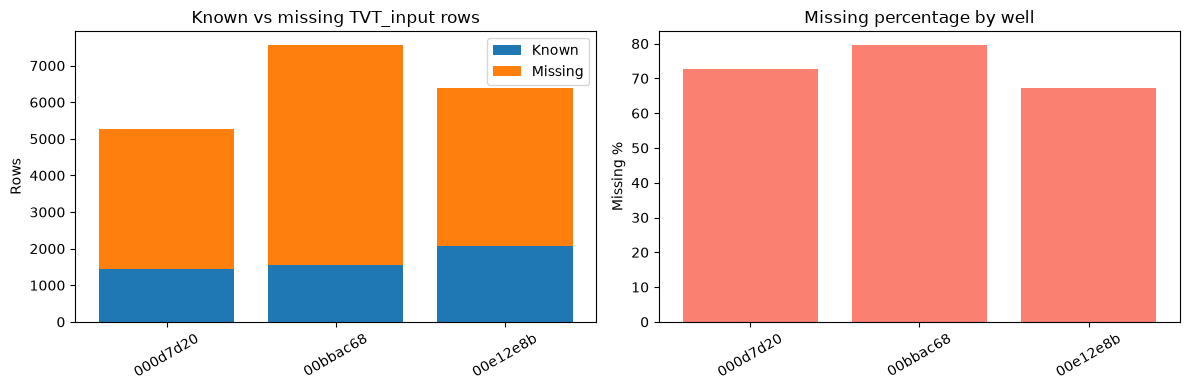

In [19]:
def analyze_known_missing(horizontal_df: pd.DataFrame, well_id: str) -> dict:
    """Analyze known vs missing TVT_input structure for one well."""
    df = horizontal_df.copy()
    if "MD" not in df.columns or "TVT_input" not in df.columns:
        raise ValueError(f"{well_id} missing MD or TVT_input")
    df = df.sort_values("MD")
    known_mask = df["TVT_input"].notna().to_numpy()
    missing_mask = ~known_mask
    n = len(df)
    n_known = int(known_mask.sum())
    n_missing = int(missing_mask.sum())

    first_missing_pos = None
    if n_missing > 0:
        first_missing_pos = int(np.argmax(missing_mask))
    last_known_pos = None
    if n_known > 0:
        last_known_pos = int(n_known - 1) if first_missing_pos is None else int(first_missing_pos - 1)

    trailing = False
    internal_gaps = 0
    if n_missing == 0:
        trailing = True
    else:
        # Contiguous trailing block: all missing after first missing, none before
        trailing = bool(missing_mask[first_missing_pos:].all() and (~missing_mask[:first_missing_pos]).all())
        # Count internal gaps as transitions from known->missing before the final trailing run
        transitions = np.diff(missing_mask.astype(int))
        internal_gaps = int(np.sum(transitions == 1) - (1 if n_missing > 0 else 0))
        if internal_gaps < 0:
            internal_gaps = 0

    last_known_md = float(df.iloc[last_known_pos]["MD"]) if last_known_pos is not None and last_known_pos >= 0 else np.nan
    first_missing_md = (
        float(df.iloc[first_missing_pos]["MD"]) if first_missing_pos is not None else np.nan
    )
    rows_after_first_missing = n - first_missing_pos if first_missing_pos is not None else 0

    return {
        "well_id": well_id,
        "total_rows": n,
        "known_rows": n_known,
        "missing_rows": n_missing,
        "known_pct": 100.0 * n_known / n if n else np.nan,
        "missing_pct": 100.0 * n_missing / n if n else np.nan,
        "last_known_row_position": last_known_pos,
        "last_known_md": last_known_md,
        "first_missing_md": first_missing_md,
        "trailing_missing_interval": trailing,
        "internal_missing_gaps": internal_gaps,
        "rows_after_first_missing": rows_after_first_missing,
        "missing_fraction": n_missing / n if n else np.nan,
    }


known_missing_rows = []
for well_id, h_df in test_horizontal_frames.items():
    stats = analyze_known_missing(h_df, well_id)
    known_missing_rows.append(stats)
    if not stats["trailing_missing_interval"]:
        print(
            f"WARNING: well {well_id} missing rows are not a strict trailing interval "
            f"(internal_gaps={stats['internal_missing_gaps']})"
        )

known_missing_df = pd.DataFrame(known_missing_rows)
known_missing_df.to_csv(TABLES_DIR / "test_known_vs_missing_summary.csv", index=False)
display(known_missing_df)

TEST_MISSING_FRACTIONS = known_missing_df["missing_fraction"].dropna().tolist()
print("Test missing fractions:", TEST_MISSING_FRACTIONS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(known_missing_df["well_id"], known_missing_df["known_rows"], label="Known")
axes[0].bar(
    known_missing_df["well_id"],
    known_missing_df["missing_rows"],
    bottom=known_missing_df["known_rows"],
    label="Missing",
)
axes[0].set_title("Known vs missing TVT_input rows")
axes[0].set_ylabel("Rows")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(known_missing_df["well_id"], known_missing_df["missing_pct"], color="salmon")
axes[1].set_title("Missing percentage by well")
axes[1].set_ylabel("Missing %")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "test_known_vs_missing.png", dpi=120, bbox_inches="tight")
plt.show()

assert known_missing_df["trailing_missing_interval"].all(), (
    "One or more test wells do not have a strict trailing missing interval"
)


# Section 5 — Inline horizontal feature engineering

Create prediction-time-safe horizontal features. Preserve original row order metadata, compute along MD-sorted order, and never use future TVT values or filled raw `TVT_input`.
Formation tops are excluded because they are absent from test horizontals.


In [20]:
RAW_HORIZONTAL_FEATURES = ["MD", "GR", "X", "Y", "Z"]
ROLLING_WINDOWS = [5, 11, 21]


def engineer_horizontal_features(horizontal_df: pd.DataFrame, well_id: str) -> pd.DataFrame:
    """
    Engineer prediction-time-safe horizontal features.

    Preserves original row index in `original_row_index`, sorts by MD for
    calculations, and uses only backward-looking rolling statistics.
    Does not include actual TVT or raw TVT_input as model features.
    """
    if horizontal_df.empty:
        raise ValueError(f"Horizontal well {well_id} is empty.")

    missing = [c for c in RAW_HORIZONTAL_FEATURES if c not in horizontal_df.columns]
    if missing:
        raise ValueError(f"Well {well_id} missing required columns: {missing}")

    df = horizontal_df.copy()
    df["original_row_index"] = df.index.astype(int)
    df["well_id"] = well_id
    df = df.sort_values("MD").reset_index(drop=True)

    md0 = df["MD"].iloc[0]
    df["MD_relative"] = df["MD"] - md0
    md_range = float(df["MD"].iloc[-1] - md0)
    df["MD_normalized"] = df["MD_relative"] / md_range if md_range > 0 else 0.0

    df["X_relative"] = df["X"] - df["X"].iloc[0]
    df["Y_relative"] = df["Y"] - df["Y"].iloc[0]
    df["Z_relative"] = df["Z"] - df["Z"].iloc[0]

    for col in ["MD", "X", "Y", "Z", "GR"]:
        df[f"{col}_diff"] = df[col].diff()

    df["step_distance_3d"] = np.sqrt(
        df["X_diff"].fillna(0.0) ** 2
        + df["Y_diff"].fillna(0.0) ** 2
        + df["Z_diff"].fillna(0.0) ** 2
    )
    df["cumulative_trajectory_distance"] = df["step_distance_3d"].cumsum()
    df["horizontal_distance"] = np.sqrt(df["X_relative"] ** 2 + df["Y_relative"] ** 2)
    df["spatial_distance"] = np.sqrt(
        df["X_relative"] ** 2 + df["Y_relative"] ** 2 + df["Z_relative"] ** 2
    )

    # Backward-looking rolling GR statistics (current + previous rows only)
    for window in ROLLING_WINDOWS:
        roll = df["GR"].rolling(window=window, min_periods=1)
        df[f"GR_roll_mean_{window}"] = roll.mean()
        df[f"GR_roll_std_{window}"] = roll.std()
        df[f"GR_dev_from_roll_mean_{window}"] = df["GR"] - df[f"GR_roll_mean_{window}"]

    # Inclination-related proxy from Z vs MD step when available
    with np.errstate(divide="ignore", invalid="ignore"):
        df["dz_dmd"] = df["Z_diff"] / df["MD_diff"].replace(0, np.nan)

    return df


# Smoke test on first train well
_smoke_well = train_registry.iloc[0]["well_id"]
_smoke_df = pd.read_csv(train_registry.iloc[0]["horizontal_path"])
_smoke_feat = engineer_horizontal_features(_smoke_df, _smoke_well)
print("Smoke feature shape:", _smoke_feat.shape)
print("Columns:", list(_smoke_feat.columns))
assert "original_row_index" in _smoke_feat.columns
assert "TVT_input" not in [c for c in _smoke_feat.columns if c.endswith("_feature")]
del _smoke_df, _smoke_feat
gc.collect()


Smoke feature shape: (5278, 39)
Columns: ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'original_row_index', 'well_id', 'MD_relative', 'MD_normalized', 'X_relative', 'Y_relative', 'Z_relative', 'MD_diff', 'X_diff', 'Y_diff', 'Z_diff', 'GR_diff', 'step_distance_3d', 'cumulative_trajectory_distance', 'horizontal_distance', 'spatial_distance', 'GR_roll_mean_5', 'GR_roll_std_5', 'GR_dev_from_roll_mean_5', 'GR_roll_mean_11', 'GR_roll_std_11', 'GR_dev_from_roll_mean_11', 'GR_roll_mean_21', 'GR_roll_std_21', 'GR_dev_from_roll_mean_21', 'dz_dmd']


6351

# Section 6 — Last-known-TVT and linear-extrapolation features

Build features from the known TVT prefix only. Slopes and projections never use hidden-row targets.


In [21]:
SLOPE_WINDOWS = [5, 10, 25, 50, 100]
PRIMARY_SLOPE_WINDOW = 50


def _safe_polyfit_slope(md_values: np.ndarray, tvt_values: np.ndarray) -> float:
    """Fit MD->TVT slope with guards for duplicates / short series."""
    if len(md_values) < 2:
        return 0.0
    if np.unique(md_values).size < 2:
        return 0.0
    try:
        slope, _ = np.polyfit(md_values, tvt_values, 1)
        if not np.isfinite(slope):
            return 0.0
        return float(slope)
    except Exception:
        return 0.0


def compute_slope_from_known(
    known_md: np.ndarray,
    known_tvt: np.ndarray,
    window: int,
) -> float:
    """Slope from the last `window` known TVT rows."""
    if len(known_md) == 0:
        return 0.0
    take = min(window, len(known_md))
    return _safe_polyfit_slope(known_md[-take:], known_tvt[-take:])


def add_last_known_and_slope_features(
    sorted_df: pd.DataFrame,
    known_mask: np.ndarray | pd.Series,
    slope_windows: list[int] | None = None,
    primary_window: int = PRIMARY_SLOPE_WINDOW,
    tvt_source_column: str = "TVT_input",
) -> pd.DataFrame:
    """
    Add last-known TVT and multi-window linear projection features.

    `known_mask` marks rows whose TVT values may be used for slopes.
    Prediction rows never contribute their actual TVT.
    """
    if slope_windows is None:
        slope_windows = SLOPE_WINDOWS

    df = sorted_df.copy()
    known_mask = np.asarray(known_mask, dtype=bool)
    if len(known_mask) != len(df):
        raise ValueError("known_mask length must match dataframe length")
    if tvt_source_column not in df.columns:
        raise ValueError(f"Missing column {tvt_source_column}")

    known_md = df.loc[known_mask, "MD"].to_numpy(dtype=float)
    known_tvt = df.loc[known_mask, tvt_source_column].to_numpy(dtype=float)
    valid = np.isfinite(known_md) & np.isfinite(known_tvt)
    known_md = known_md[valid]
    known_tvt = known_tvt[valid]

    if len(known_tvt) == 0:
        last_known_tvt = np.nan
        last_known_md = np.nan
        first_known_md = np.nan
    else:
        last_known_tvt = float(known_tvt[-1])
        last_known_md = float(known_md[-1])
        first_known_md = float(known_md[0])

    slopes = {
        window: compute_slope_from_known(known_md, known_tvt, window)
        for window in slope_windows
    }
    primary_slope = slopes.get(primary_window, 0.0)
    slope_values = np.array(list(slopes.values()), dtype=float)

    df["last_known_tvt"] = last_known_tvt
    df["last_known_md"] = last_known_md
    df["distance_from_last_known_md"] = df["MD"] - last_known_md
    df["known_tvt_count"] = float(len(known_tvt))
    df["known_fraction"] = float(len(known_tvt) / len(df)) if len(df) else 0.0
    df["md_relative_to_first_known"] = df["MD"] - first_known_md
    df["distance_beyond_known_interval"] = np.maximum(df["MD"] - last_known_md, 0.0)

    for window, slope in slopes.items():
        df[f"tvt_slope_w{window}"] = slope
        df[f"linear_proj_w{window}"] = last_known_tvt + slope * (df["MD"] - last_known_md)

    df["recent_tvt_slope"] = primary_slope
    df["linear_tvt_projection"] = last_known_tvt + primary_slope * (df["MD"] - last_known_md)

    if len(slope_windows) >= 2:
        short_w = min(slope_windows)
        long_w = max(slope_windows)
        df["slope_long_minus_short"] = slopes[long_w] - slopes[short_w]
    else:
        df["slope_long_minus_short"] = 0.0

    df["slope_mean"] = float(np.mean(slope_values)) if len(slope_values) else 0.0
    df["slope_std"] = float(np.std(slope_values)) if len(slope_values) else 0.0
    df["slope_median"] = float(np.median(slope_values)) if len(slope_values) else 0.0
    df["linear_proj_median_slope"] = last_known_tvt + df["slope_median"] * (
        df["MD"] - last_known_md
    )

    return df


# Smoke test
_smoke_well = train_registry.iloc[0]["well_id"]
_smoke_df = pd.read_csv(train_registry.iloc[0]["horizontal_path"])
_smoke_feat = engineer_horizontal_features(_smoke_df, _smoke_well)
_known = _smoke_feat["TVT_input"].notna().to_numpy() if "TVT_input" in _smoke_feat.columns else np.zeros(len(_smoke_feat), dtype=bool)
# Re-attach TVT_input from sorted original for smoke if needed
if "TVT_input" not in _smoke_feat.columns:
    tmp = _smoke_df.copy()
    tmp["original_row_index"] = tmp.index.astype(int)
    tmp = tmp.sort_values("MD").reset_index(drop=True)
    _smoke_feat["TVT_input"] = tmp["TVT_input"].to_numpy()
    _known = _smoke_feat["TVT_input"].notna().to_numpy()
_smoke_slope = add_last_known_and_slope_features(_smoke_feat, _known)
print("Slope feature columns added. linear_tvt_projection finite:",
      np.isfinite(_smoke_slope["linear_tvt_projection"]).mean())
del _smoke_df, _smoke_feat, _smoke_slope
gc.collect()


Slope feature columns added. linear_tvt_projection finite: 1.0


0

# Section 7 — Simulate Kaggle-style masking on training wells

Use the natural trailing `TVT_input` mask when present, and optionally add controlled earlier cut-points so known prefixes resemble the test missing-fraction distribution.
Features for hidden rows use only the known prefix.


In [22]:
MIN_KNOWN_ROWS = 50
MIN_HIDDEN_ROWS = 20
MAX_MASKS_PER_WELL = 2
# MAX_HIDDEN_ROWS_PER_MASK comes from the Section 1 speed profile.
CONTROLLED_FRACTIONS = [0.15, 0.25, 0.35, 0.50]
print(f"Using MAX_HIDDEN_ROWS_PER_MASK={MAX_HIDDEN_ROWS_PER_MASK}")


def load_csv(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path)


def prepare_well_frame(horizontal_df: pd.DataFrame, well_id: str) -> pd.DataFrame:
    """Attach TVT columns needed for masking onto engineered features."""
    raw = horizontal_df.copy()
    raw["original_row_index"] = raw.index.astype(int)
    feat = engineer_horizontal_features(raw, well_id)
    # Merge target / TVT_input by original_row_index after MD sort in engineer_
    raw_sorted = raw.sort_values("MD").reset_index(drop=True)
    for col in ["TVT_input", "TVT"]:
        if col in raw_sorted.columns:
            feat[col] = raw_sorted[col].to_numpy()
        elif col not in feat.columns:
            feat[col] = np.nan
    return feat


def find_natural_cut(sorted_df: pd.DataFrame) -> int | None:
    """Return first missing TVT_input position if trailing, else None."""
    if "TVT_input" not in sorted_df.columns:
        return None
    missing = sorted_df["TVT_input"].isna().to_numpy()
    if not missing.any():
        return None
    first = int(np.argmax(missing))
    if missing[first:].all() and (~missing[:first]).all():
        return first
    return None


def candidate_cut_positions(
    n_rows: int,
    natural_cut: int | None,
    test_fractions: list[float],
    rng: np.random.Generator,
) -> list[tuple[str, int, float]]:
    """Build up to MAX_MASKS_PER_WELL valid (mask_name, cut_pos, hidden_fraction)."""
    candidates: list[tuple[str, int, float]] = []

    def try_add(name: str, cut: int) -> None:
        known = cut
        hidden = n_rows - cut
        if known < MIN_KNOWN_ROWS or hidden < MIN_HIDDEN_ROWS:
            return
        frac = hidden / n_rows
        candidates.append((name, cut, frac))

    if natural_cut is not None:
        try_add("natural", natural_cut)

    frac_pool = list(test_fractions) + list(CONTROLLED_FRACTIONS)
    frac_pool = sorted(set(round(float(f), 4) for f in frac_pool if np.isfinite(f)))
    rng.shuffle(frac_pool)

    for frac in frac_pool:
        cut = int(round(n_rows * (1.0 - frac)))
        cut = max(MIN_KNOWN_ROWS, min(cut, n_rows - MIN_HIDDEN_ROWS))
        try_add(f"frac_{frac:.2f}", cut)
        if len(candidates) >= MAX_MASKS_PER_WELL * 3:
            break

    # Deduplicate by cut position, prefer natural first
    seen_cuts = set()
    selected = []
    for item in candidates:
        if item[1] in seen_cuts:
            continue
        seen_cuts.add(item[1])
        selected.append(item)
        if len(selected) >= MAX_MASKS_PER_WELL:
            break
    return selected


def _subsample_hidden_frame(hidden: pd.DataFrame, max_rows: int) -> pd.DataFrame:
    """Evenly subsample hidden rows along MD to keep memory bounded."""
    if len(hidden) <= max_rows:
        return hidden
    idx = np.linspace(0, len(hidden) - 1, max_rows).astype(int)
    return hidden.iloc[idx].copy()


def build_masked_rows_for_well(
    horizontal_df: pd.DataFrame,
    well_id: str,
    typewell_df: pd.DataFrame | None,
    test_fractions: list[float],
    rng: np.random.Generator,
    include_typewell: bool = False,
) -> tuple[pd.DataFrame, list[dict]]:
    """
    Create masked prediction rows for one training well (vectorized).

    Returns (hidden_rows_dataframe, mask_summary_dicts).
    """
    feat = prepare_well_frame(horizontal_df, well_id)
    usable = feat["TVT"].notna() if "TVT" in feat.columns else pd.Series(False, index=feat.index)
    if usable.sum() < (MIN_KNOWN_ROWS + MIN_HIDDEN_ROWS):
        return pd.DataFrame(), []

    # Restrict to contiguous usable target rows sorted by MD (already sorted)
    feat = feat.loc[usable].reset_index(drop=True)
    n_rows = len(feat)
    natural_cut = find_natural_cut(feat)

    cuts = candidate_cut_positions(n_rows, natural_cut, test_fractions, rng)
    frames: list[pd.DataFrame] = []
    summaries: list[dict] = []

    for mask_num, (mask_name, cut, hidden_frac) in enumerate(cuts, start=1):
        known_mask = np.zeros(n_rows, dtype=bool)
        known_mask[:cut] = True
        # Simulated TVT_input: keep prefix values, hide the rest
        sim = feat.copy()
        sim["sim_TVT_input"] = np.nan
        sim.loc[known_mask, "sim_TVT_input"] = sim.loc[known_mask, "TVT"].to_numpy()

        slope_frame = add_last_known_and_slope_features(
            sim,
            known_mask,
            slope_windows=SLOPE_WINDOWS,
            primary_window=PRIMARY_SLOPE_WINDOW,
            tvt_source_column="sim_TVT_input",
        )

        if include_typewell and typewell_df is not None:
            slope_frame = build_typewell_features(slope_frame, typewell_df)

        hidden = slope_frame.loc[~known_mask].copy()
        ok = np.isfinite(hidden["TVT"].to_numpy(dtype=float)) & np.isfinite(
            hidden["linear_tvt_projection"].to_numpy(dtype=float)
        )
        hidden = hidden.loc[ok]
        n_hidden_full = len(hidden)
        hidden = _subsample_hidden_frame(hidden, MAX_HIDDEN_ROWS_PER_MASK)

        if hidden.empty:
            continue

        hidden["well_id"] = well_id
        hidden["mask_id"] = f"{well_id}__{mask_name}"
        hidden["mask_number"] = mask_num
        hidden["mask_name"] = mask_name
        hidden["actual_tvt"] = hidden["TVT"].astype(float)
        hidden["residual_target"] = (
            hidden["actual_tvt"] - hidden["linear_tvt_projection"].astype(float)
        )
        hidden["group_id"] = well_id
        frames.append(hidden)

        summaries.append(
            {
                "well_id": well_id,
                "mask_number": mask_num,
                "mask_name": mask_name,
                "total_usable_rows": n_rows,
                "known_rows": int(cut),
                "hidden_rows": int(n_rows - cut),
                "hidden_rows_used": int(len(hidden)),
                "hidden_rows_full": int(n_hidden_full),
                "hidden_fraction": float(hidden_frac),
                "last_known_md": float(slope_frame.iloc[cut - 1]["MD"]),
                "first_hidden_md": float(slope_frame.iloc[cut]["MD"]),
            }
        )

        del sim, slope_frame, hidden

    if not frames:
        return pd.DataFrame(), summaries
    return pd.concat(frames, ignore_index=True), summaries


# Build masking summary over a small preview of wells for inspection
_preview_ids = train_registry["well_id"].head(5).tolist()
_preview_summaries = []
_rng_preview = np.random.default_rng(RANDOM_STATE)
for _wid in _preview_ids:
    _hpath = train_registry.loc[train_registry["well_id"] == _wid, "horizontal_path"].iloc[0]
    _rows, _sums = build_masked_rows_for_well(
        load_csv(_hpath),
        _wid,
        None,
        TEST_MISSING_FRACTIONS,
        _rng_preview,
        include_typewell=False,
    )
    _preview_summaries.extend(_sums)
    print(f"Preview well {_wid}: masks={len(_sums)}, hidden_rows={len(_rows)}")

preview_mask_df = pd.DataFrame(_preview_summaries)
display(preview_mask_df)
print("Masking helpers ready. Full datasets are built in Section 8.")


Using MAX_HIDDEN_ROWS_PER_MASK=1500
Preview well 000d7d20: masks=2, hidden_rows=3000
Preview well 00bbac68: masks=2, hidden_rows=2634
Preview well 00e12e8b: masks=2, hidden_rows=3000
Preview well 015fe0d2: masks=2, hidden_rows=2392
Preview well 01869cd4: masks=2, hidden_rows=3000


,well_id,mask_number,mask_name,total_usable_rows,known_rows,hidden_rows,hidden_rows_used,hidden_rows_full,hidden_fraction,last_known_md,first_hidden_md
0,000d7d20,1,natural,5278,1442,3836,1500,3836,0.726790,12908.0,12909.0
1,000d7d20,2,frac_0.50,5278,2639,2639,1500,2639,0.500000,14105.0,14106.0
2,00bbac68,1,natural,7559,1545,6014,1500,6014,0.795608,13122.0,13123.0
3,00bbac68,2,frac_0.15,7559,6425,1134,1134,1134,0.150020,18002.0,18003.0
4,00e12e8b,1,natural,6384,2083,4301,1500,4301,0.673716,12538.0,12539.0
5,00e12e8b,2,frac_0.80,6384,1305,5079,1500,5079,0.795583,11760.0,11761.0
6,015fe0d2,1,natural,5950,1654,4296,1500,4296,0.722017,13487.0,13488.0
7,015fe0d2,2,frac_0.15,5950,5058,892,892,892,0.149916,16891.0,16892.0
8,01869cd4,1,natural,6850,1293,5557,1500,5557,0.811241,12548.0,12549.0
9,01869cd4,2,frac_0.25,6850,5138,1712,1500,1712,0.249927,16393.0,16394.0


Masking helpers ready. Full datasets are built in Section 8.


# Section 8 — Build realistic masked training and validation datasets

Split wells first, then construct masked prediction rows separately for training and validation wells so groups never leak across the split.

This build is memory-safe: hidden rows are capped per mask, written in parquet chunks, and downcast so the kernel does not die on ~16GB machines.


In [23]:
# Typewell helper defined here so Section 7 preview can optionally skip it;
# full implementation used from Section 10 onward and for final datasets.


def build_typewell_features(
    horizontal_features: pd.DataFrame,
    typewell_df: pd.DataFrame,
    n_neighbors: int = 15,
) -> pd.DataFrame:
    """
    Add typewell-derived features using only GR/TVT from the paired typewell.

    Operates independently per well. Avoids Geology (absent on test typewells).
    Does not use horizontal target TVT. Uses vectorized nearest-neighbor lookup.
    """
    df = horizontal_features.copy()
    empty_cols = [
        "tw_nearest_tvt",
        "tw_nearest_gr_distance",
        "tw_local_tvt_mean",
        "tw_local_tvt_std",
        "tw_gr_percentile",
        "tw_gr_mean",
        "tw_gr_std",
        "tw_gr_min",
        "tw_gr_max",
        "tw_tvt_min",
        "tw_tvt_max",
        "tw_tvt_range",
        "tw_interp_tvt_by_gr",
    ]

    if typewell_df is None or "GR" not in typewell_df.columns or "TVT" not in typewell_df.columns:
        for col in empty_cols:
            df[col] = np.nan
        return df

    tw = typewell_df[["GR", "TVT"]].replace([np.inf, -np.inf], np.nan).dropna()
    if tw.empty:
        for col in empty_cols:
            df[col] = np.nan
        return df

    tw_gr = tw["GR"].to_numpy(dtype=float)
    tw_tvt = tw["TVT"].to_numpy(dtype=float)
    tw_gr_mean = float(np.mean(tw_gr))
    tw_gr_std = float(np.std(tw_gr)) if len(tw_gr) > 1 else 1.0
    if tw_gr_std == 0:
        tw_gr_std = 1.0

    df["tw_gr_mean"] = tw_gr_mean
    df["tw_gr_std"] = tw_gr_std
    df["tw_gr_min"] = float(np.min(tw_gr))
    df["tw_gr_max"] = float(np.max(tw_gr))
    df["tw_tvt_min"] = float(np.min(tw_tvt))
    df["tw_tvt_max"] = float(np.max(tw_tvt))
    df["tw_tvt_range"] = df["tw_tvt_max"] - df["tw_tvt_min"]

    order = np.argsort(tw_gr)
    tw_gr_sorted = tw_gr[order]
    tw_tvt_sorted = tw_tvt[order]
    _, unique_idx = np.unique(tw_gr_sorted, return_index=True)
    tw_gr_unique = tw_gr_sorted[unique_idx]
    tw_tvt_unique = tw_tvt_sorted[unique_idx]

    h_gr = df["GR"].to_numpy(dtype=float)
    n = len(h_gr)
    nearest_tvt = np.full(n, np.nan)
    nearest_dist = np.full(n, np.nan)
    local_mean = np.full(n, np.nan)
    local_std = np.full(n, np.nan)
    percentiles = np.full(n, np.nan)
    interp_tvt = np.full(n, np.nan)

    valid = np.isfinite(h_gr)
    if valid.any():
        # Nearest by GR via searchsorted on sorted typewell GR
        pos = np.searchsorted(tw_gr_sorted, h_gr[valid], side="left")
        left = np.clip(pos - 1, 0, len(tw_gr_sorted) - 1)
        right = np.clip(pos, 0, len(tw_gr_sorted) - 1)
        choose_right = np.abs(tw_gr_sorted[right] - h_gr[valid]) < np.abs(
            tw_gr_sorted[left] - h_gr[valid]
        )
        nearest_pos = np.where(choose_right, right, left)
        nearest_tvt[valid] = tw_tvt_sorted[nearest_pos]
        nearest_dist[valid] = np.abs(tw_gr_sorted[nearest_pos] - h_gr[valid])

        # Local window around nearest index for mean/std
        k = min(n_neighbors, len(tw_gr_sorted))
        half = k // 2
        starts = np.clip(nearest_pos - half, 0, len(tw_gr_sorted) - k)
        # Gather neighbors with broadcasting
        offsets = np.arange(k)
        neighbor_idx = starts[:, None] + offsets[None, :]
        neighbor_tvt = tw_tvt_sorted[neighbor_idx]
        local_mean[valid] = neighbor_tvt.mean(axis=1)
        local_std[valid] = neighbor_tvt.std(axis=1) if k > 1 else 0.0

        # Percentile of GR within typewell
        percentiles[valid] = (
            np.searchsorted(tw_gr_sorted, h_gr[valid], side="right") / len(tw_gr_sorted) * 100.0
        )

        if len(tw_gr_unique) >= 2:
            interp_tvt[valid] = np.interp(h_gr[valid], tw_gr_unique, tw_tvt_unique)
        else:
            interp_tvt[valid] = tw_tvt_unique[0]

    df["tw_nearest_tvt"] = nearest_tvt
    df["tw_nearest_gr_distance"] = nearest_dist
    df["tw_local_tvt_mean"] = local_mean
    df["tw_local_tvt_std"] = local_std
    df["tw_gr_percentile"] = percentiles
    df["tw_interp_tvt_by_gr"] = interp_tvt
    return df

META_COLUMNS = {
    "well_id",
    "mask_id",
    "mask_number",
    "mask_name",
    "group_id",
    "original_row_index",
    "actual_tvt",
    "residual_target",
    "TVT",
    "TVT_input",
    "sim_TVT_input",
}


def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast float64/int64 to save RAM on large masked datasets."""
    if df.empty:
        return df
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_float_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_integer_dtype(out[col]) and col not in {
            "mask_number",
            "original_row_index",
        }:
            out[col] = pd.to_numeric(out[col], downcast="integer")
    return out


def build_dataset_for_wells(
    well_ids: list[str],
    registry: pd.DataFrame,
    test_fractions: list[float],
    random_state: int,
    include_typewell: bool = True,
    chunk_size: int = 25,
    cache_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build masked prediction-row dataset for a list of wells.

    Writes intermediate parquet chunks to disk so peak RAM stays bounded,
    then concatenates the chunks into the final DataFrame.
    """
    rng = np.random.default_rng(random_state)
    all_summaries: list[dict] = []
    registry_indexed = registry.set_index("well_id")
    chunk_frames: list[pd.DataFrame] = []
    chunk_paths: list[Path] = []
    rows_written = 0
    cache_dir = TABLES_DIR / "_masked_chunks"
    if cache_name:
        cache_dir = TABLES_DIR / f"_masked_chunks_{cache_name}"
    if cache_dir.exists():
        for old in cache_dir.glob("*.parquet"):
            old.unlink()
    cache_dir.mkdir(parents=True, exist_ok=True)

    def flush_chunk(force: bool = False) -> None:
        nonlocal chunk_frames, rows_written
        if not chunk_frames:
            return
        if not force and len(chunk_frames) < chunk_size:
            return
        combined = downcast_numeric(pd.concat(chunk_frames, ignore_index=True))
        path = cache_dir / f"chunk_{len(chunk_paths):04d}.parquet"
        combined.to_parquet(path, index=False)
        rows_written += len(combined)
        chunk_paths.append(path)
        chunk_frames = []
        del combined
        gc.collect()

    for i, well_id in enumerate(well_ids):
        row = registry_indexed.loc[well_id]
        horizontal_df = load_csv(row["horizontal_path"])
        typewell_df = load_csv(row["typewell_path"]) if include_typewell else None
        rows_df, summaries = build_masked_rows_for_well(
            horizontal_df,
            well_id,
            typewell_df,
            test_fractions,
            rng,
            include_typewell=include_typewell,
        )
        all_summaries.extend(summaries)
        if not rows_df.empty:
            chunk_frames.append(rows_df)
        del horizontal_df, typewell_df, rows_df
        flush_chunk(force=False)
        if (i + 1) % 50 == 0 or (i + 1) == len(well_ids):
            n_mem = sum(len(f) for f in chunk_frames)
            print(f"  processed {i + 1}/{len(well_ids)} wells; rows so far={rows_written + n_mem}")
            gc.collect()

    flush_chunk(force=True)

    if not chunk_paths:
        return pd.DataFrame(), pd.DataFrame(all_summaries)

    parts = [pd.read_parquet(p) for p in chunk_paths]
    result = downcast_numeric(pd.concat(parts, ignore_index=True))
    del parts
    gc.collect()
    return result, pd.DataFrame(all_summaries)


all_train_well_ids = train_registry["well_id"].tolist()
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
# GroupShuffleSplit needs X, y, groups — use dummy X
_dummy = np.zeros(len(all_train_well_ids))
_groups = np.array(all_train_well_ids)
train_idx, val_idx = next(gss.split(_dummy, groups=_groups))
SPLIT_TRAIN_WELLS = sorted(_groups[train_idx].tolist())
SPLIT_VAL_WELLS = sorted(_groups[val_idx].tolist())

assert not set(SPLIT_TRAIN_WELLS) & set(SPLIT_VAL_WELLS)
print(f"Train wells: {len(SPLIT_TRAIN_WELLS)}")
print(f"Validation wells: {len(SPLIT_VAL_WELLS)}")
print(f"MAX_HIDDEN_ROWS_PER_MASK={MAX_HIDDEN_ROWS_PER_MASK}")

print("Building training masked dataset...")
train_masked_df, train_mask_summary_df = build_dataset_for_wells(
    SPLIT_TRAIN_WELLS,
    train_registry,
    TEST_MISSING_FRACTIONS,
    random_state=RANDOM_STATE,
    include_typewell=True,
    cache_name="train",
)
print("Building validation masked dataset...")
val_masked_df, val_mask_summary_df = build_dataset_for_wells(
    SPLIT_VAL_WELLS,
    train_registry,
    TEST_MISSING_FRACTIONS,
    random_state=RANDOM_STATE + 1,
    include_typewell=True,
    cache_name="val",
)

mask_summary_df = pd.concat([train_mask_summary_df, val_mask_summary_df], ignore_index=True)
mask_summary_df.to_csv(TABLES_DIR / "masking_summary.csv", index=False)

# Determine model feature columns: numeric, available, not meta/target
exclude_from_features = META_COLUMNS | {
    "linear_proj_w5",
    "linear_proj_w10",
    "linear_proj_w25",
    "linear_proj_w50",
    "linear_proj_w100",
    "linear_proj_median_slope",
}  # keep linear_tvt_projection as a feature AND for reconstruction


def infer_feature_columns(df: pd.DataFrame) -> list[str]:
    cols = []
    for col in df.columns:
        if col in META_COLUMNS:
            continue
        if col in {"linear_tvt_projection"}:
            cols.append(col)
            continue
        if col.startswith("linear_proj_"):
            # keep alternate projections as features
            cols.append(col)
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            cols.append(col)
    # Stable order
    return sorted(cols)


FEATURE_COLUMNS = infer_feature_columns(train_masked_df)
# Ensure critical columns present
for required in ["MD", "GR", "X", "Y", "Z", "linear_tvt_projection", "last_known_tvt"]:
    if required not in FEATURE_COLUMNS and required in train_masked_df.columns:
        FEATURE_COLUMNS.append(required)
FEATURE_COLUMNS = sorted(set(FEATURE_COLUMNS))

with open(METADATA_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

print("Train prediction rows:", len(train_masked_df))
print("Val prediction rows:", len(val_masked_df))
print("Feature count:", len(FEATURE_COLUMNS))
print("Train masks:", len(train_mask_summary_df), "Val masks:", len(val_mask_summary_df))
if len(train_masked_df):
    print(
        "Approx train memory (MB):",
        round(train_masked_df.memory_usage(deep=True).sum() / 1e6, 1),
    )
print("Residual target stats (train):")
display(train_masked_df["residual_target"].describe())
print("Missing feature rates (train, top 10):")
miss_rates = train_masked_df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False)
display(miss_rates.head(10))

train_mask_summary_df.to_csv(TABLES_DIR / "train_masking_summary.csv", index=False)
val_mask_summary_df.to_csv(TABLES_DIR / "val_masking_summary.csv", index=False)
train_masked_df.head(1000).to_parquet(TABLES_DIR / "train_masked_sample.parquet", index=False)
val_masked_df.head(1000).to_parquet(TABLES_DIR / "val_masked_sample.parquet", index=False)


Train wells: 618
Validation wells: 155
MAX_HIDDEN_ROWS_PER_MASK=1500
Building training masked dataset...
  processed 50/618 wells; rows so far=144111
  processed 100/618 wells; rows so far=288447
  processed 150/618 wells; rows so far=436707
  processed 200/618 wells; rows so far=579298
  processed 250/618 wells; rows so far=727830
  processed 300/618 wells; rows so far=874162
  processed 350/618 wells; rows so far=1020585
  processed 400/618 wells; rows so far=1164513
  processed 450/618 wells; rows so far=1310283
  processed 500/618 wells; rows so far=1457313
  processed 550/618 wells; rows so far=1602957
  processed 600/618 wells; rows so far=1751035
  processed 618/618 wells; rows so far=1802041
Building validation masked dataset...
  processed 50/155 wells; rows so far=147865
  processed 100/155 wells; rows so far=293890
  processed 150/155 wells; rows so far=437623
  processed 155/155 wells; rows so far=451883
Train prediction rows: 1802041
Val prediction rows: 451883
Feature cou

count    1.802041e+06
mean    -6.614945e+00
std      1.097444e+02
min     -2.425279e+03
25%     -2.034818e+01
50%     -8.593278e-02
75%      1.970924e+01
max      6.289901e+02
Name: residual_target, dtype: float64

Missing feature rates (train, top 10):


GR_diff                     0.483678
GR                          0.314513
tw_interp_tvt_by_gr         0.314513
GR_dev_from_roll_mean_11    0.314513
tw_local_tvt_std            0.314513
GR_dev_from_roll_mean_5     0.314513
GR_dev_from_roll_mean_21    0.314513
tw_nearest_gr_distance      0.314513
tw_gr_percentile            0.314513
tw_nearest_tvt              0.314513
dtype: float64

# Section 9 — Evaluate domain baselines

Evaluate last-known and linear-projection baselines on the realistic validation hidden rows. The learned residual model must beat the strongest baseline.


last_known_tvt: RMSE=16.2150 MAE=10.8268 mean_well_RMSE=13.0860
linear_primary: RMSE=106.0086 MAE=49.6844 mean_well_RMSE=66.4469
linear_w5: RMSE=93.8914 MAE=46.4029 mean_well_RMSE=61.1949
linear_w10: RMSE=96.7035 MAE=47.1986 mean_well_RMSE=62.3733
linear_w25: RMSE=102.4003 MAE=48.3268 mean_well_RMSE=64.2429
linear_w50: RMSE=106.0086 MAE=49.6844 mean_well_RMSE=66.4469
linear_w100: RMSE=105.9173 MAE=50.5894 mean_well_RMSE=67.3722
linear_median_slope: RMSE=101.0196 MAE=47.6405 mean_well_RMSE=63.2262


,model,rmse,mae,n_rows,n_wells,mean_well_rmse,median_well_rmse,mean_well_mae,median_well_mae,max_well_rmse
0,last_known_tvt,16.214981,10.826793,451883,155,13.085987,10.428438,10.778554,8.560174,54.298396
2,linear_w5,93.891410,46.402914,451883,155,61.194884,42.004490,45.780220,32.024444,570.396201
3,linear_w10,96.703469,47.198611,451883,155,62.373284,43.626633,46.562814,33.242987,586.299865
7,linear_median_slope,101.019569,47.640547,451883,155,63.226185,44.182149,46.989263,32.993130,606.048762
4,linear_w25,102.400306,48.326789,451883,155,64.242861,44.594467,47.661326,33.526679,606.048205
6,linear_w100,105.917288,50.589404,451883,155,67.372208,49.179865,49.927747,35.968175,618.588730
1,linear_primary,106.008575,49.684434,451883,155,66.446928,46.665632,49.018284,35.331367,621.499973
5,linear_w50,106.008575,49.684434,451883,155,66.446928,46.665632,49.018284,35.331367,621.499973


Strongest domain baseline: last_known_tvt (RMSE=16.2150)


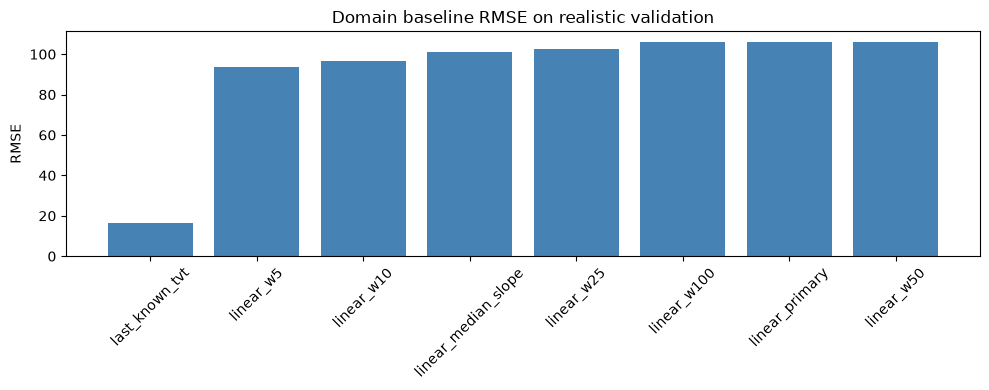

In [24]:
def calculate_rmse(y_true, y_pred) -> float:
    """RMSE compatible with older and newer scikit-learn versions."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def calculate_validation_metrics(
    y_true,
    y_pred,
    well_ids,
    model_name: str,
) -> tuple[dict, pd.DataFrame]:
    """Compute overall and per-well validation metrics."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    well_ids = np.asarray(well_ids)

    overall = {
        "model": model_name,
        "rmse": calculate_rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "n_rows": int(len(y_true)),
        "n_wells": int(pd.Series(well_ids).nunique()),
    }

    frame = pd.DataFrame({"well_id": well_ids, "y_true": y_true, "y_pred": y_pred})
    records = []
    for well_id, g in frame.groupby("well_id", sort=True):
        records.append(
            {
                "well_id": well_id,
                "rmse": calculate_rmse(g["y_true"], g["y_pred"]),
                "mae": float(mean_absolute_error(g["y_true"], g["y_pred"])),
                "n_rows": len(g),
            }
        )
    per_well = pd.DataFrame(records)

    overall["mean_well_rmse"] = float(per_well["rmse"].mean())
    overall["median_well_rmse"] = float(per_well["rmse"].median())
    overall["mean_well_mae"] = float(per_well["mae"].mean())
    overall["median_well_mae"] = float(per_well["mae"].median())
    overall["max_well_rmse"] = float(per_well["rmse"].max())
    per_well["model"] = model_name
    return overall, per_well


y_val = val_masked_df["actual_tvt"].to_numpy(dtype=float)
wells_val = val_masked_df["well_id"].to_numpy()

baseline_predictions = {
    "last_known_tvt": val_masked_df["last_known_tvt"].to_numpy(dtype=float),
    "linear_primary": val_masked_df["linear_tvt_projection"].to_numpy(dtype=float),
}
for window in SLOPE_WINDOWS:
    col = f"linear_proj_w{window}"
    if col in val_masked_df.columns:
        baseline_predictions[f"linear_w{window}"] = val_masked_df[col].to_numpy(dtype=float)
if "linear_proj_median_slope" in val_masked_df.columns:
    baseline_predictions["linear_median_slope"] = val_masked_df[
        "linear_proj_median_slope"
    ].to_numpy(dtype=float)

baseline_overall_rows = []
baseline_per_well_frames = []
for name, preds in baseline_predictions.items():
    overall, per_well = calculate_validation_metrics(y_val, preds, wells_val, name)
    baseline_overall_rows.append(overall)
    baseline_per_well_frames.append(per_well)
    print(
        f"{name}: RMSE={overall['rmse']:.4f} MAE={overall['mae']:.4f} "
        f"mean_well_RMSE={overall['mean_well_rmse']:.4f}"
    )

baseline_comparison_df = pd.DataFrame(baseline_overall_rows).sort_values("rmse")
baseline_per_well_df = pd.concat(baseline_per_well_frames, ignore_index=True)
baseline_comparison_df.to_csv(TABLES_DIR / "baseline_comparison.csv", index=False)
baseline_per_well_df.to_csv(TABLES_DIR / "baseline_per_well.csv", index=False)
display(baseline_comparison_df)

BEST_BASELINE_NAME = baseline_comparison_df.iloc[0]["model"]
BEST_BASELINE_RMSE = float(baseline_comparison_df.iloc[0]["rmse"])
print(f"Strongest domain baseline: {BEST_BASELINE_NAME} (RMSE={BEST_BASELINE_RMSE:.4f})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(baseline_comparison_df["model"], baseline_comparison_df["rmse"], color="steelblue")
ax.set_ylabel("RMSE")
ax.set_title("Domain baseline RMSE on realistic validation")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_rmse_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


# Section 10 — Add typewell-derived features

Typewell features were built during dataset construction via `build_typewell_features` using only each well's paired typewell `GR`/`TVT` values (no Geology — absent on test).

This section verifies typewell columns exist and optionally compares a quick Extra Trees residual fit with versus without typewell features on a subsample for sanity.


In [25]:
TYPEWELL_FEATURE_PREFIXES = ("tw_",)
typewell_feature_columns = [c for c in FEATURE_COLUMNS if c.startswith("tw_")]
non_typewell_feature_columns = [c for c in FEATURE_COLUMNS if not c.startswith("tw_")]

print(f"Typewell features ({len(typewell_feature_columns)}):", typewell_feature_columns)
print(f"Non-typewell features: {len(non_typewell_feature_columns)}")

assert len(typewell_feature_columns) > 0, "Expected typewell features in the training matrix"

# Quick sanity comparison on a row subsample (computationally practical)
_sample_n = min(50000, len(train_masked_df), len(val_masked_df))
_train_sample = train_masked_df.sample(n=min(_sample_n, len(train_masked_df)), random_state=RANDOM_STATE)
_val_sample = val_masked_df.sample(n=min(_sample_n, len(val_masked_df)), random_state=RANDOM_STATE)


def _median_impute_fit_transform(train_df, val_df, columns):
    medians = train_df[columns].median(numeric_only=True)
    X_train = train_df[columns].fillna(medians).to_numpy(dtype=np.float32)
    X_val = val_df[columns].fillna(medians).to_numpy(dtype=np.float32)
    return X_train, X_val, medians


_y_tr = _train_sample["residual_target"].to_numpy(dtype=np.float32)
_y_va = _val_sample["actual_tvt"].to_numpy(dtype=float)
_proj_va = _val_sample["linear_tvt_projection"].to_numpy(dtype=float)
_wells_va = _val_sample["well_id"].to_numpy()

typewell_compare_rows = []
for label, cols in [
    ("without_typewell", non_typewell_feature_columns),
    ("with_typewell", FEATURE_COLUMNS),
]:
    Xtr, Xva, _ = _median_impute_fit_transform(_train_sample, _val_sample, cols)
    et_quick = ExtraTreesRegressor(
        n_estimators=min(80, int(ET_N_ESTIMATORS)),
        max_depth=int(ET_MAX_DEPTH),
        min_samples_leaf=int(ET_MIN_SAMPLES_LEAF),
        max_features=ET_MAX_FEATURES,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    et_quick.fit(Xtr, _y_tr)
    resid_hat = et_quick.predict(Xva)
    tvt_hat = _proj_va + resid_hat
    overall, _ = calculate_validation_metrics(_y_va, tvt_hat, _wells_va, label)
    typewell_compare_rows.append(overall)
    print(f"{label}: RMSE={overall['rmse']:.4f}")

typewell_compare_df = pd.DataFrame(typewell_compare_rows)
typewell_compare_df.to_csv(TABLES_DIR / "typewell_feature_comparison_subsample.csv", index=False)
display(typewell_compare_df)
del _train_sample, _val_sample, Xtr, Xva, et_quick
gc.collect()


Typewell features (13): ['tw_gr_max', 'tw_gr_mean', 'tw_gr_min', 'tw_gr_percentile', 'tw_gr_std', 'tw_interp_tvt_by_gr', 'tw_local_tvt_mean', 'tw_local_tvt_std', 'tw_nearest_gr_distance', 'tw_nearest_tvt', 'tw_tvt_max', 'tw_tvt_min', 'tw_tvt_range']
Non-typewell features: 59
without_typewell: RMSE=19.9283
with_typewell: RMSE=19.7473


,model,rmse,mae,n_rows,n_wells,mean_well_rmse,median_well_rmse,mean_well_mae,median_well_mae,max_well_rmse
0,without_typewell,19.928327,11.901174,50000,155,14.857441,11.210233,11.764547,9.197347,88.147062
1,with_typewell,19.747296,11.995583,50000,155,14.866652,11.611770,11.865462,9.500366,89.917270


3397

# Section 11 — Train Extra Trees residual model

Train a **light** Extra Trees residual model on a row subsample for speed. Full-data Extra Trees is only fit later if the selected recipe needs it.


In [26]:
def fit_median_imputer(train_df: pd.DataFrame, columns: list[str]) -> pd.Series:
    return train_df[columns].median(numeric_only=True)


def transform_with_medians(df: pd.DataFrame, columns: list[str], medians: pd.Series) -> np.ndarray:
    return df[columns].fillna(medians).to_numpy(dtype=np.float32)


train_medians = fit_median_imputer(train_masked_df, FEATURE_COLUMNS)
train_medians.to_csv(TABLES_DIR / "train_feature_medians.csv", header=["median"])

y_train_residual_full = train_masked_df["residual_target"].to_numpy(dtype=np.float32)
resid_q_low, resid_q_high = np.quantile(y_train_residual_full, [0.01, 0.99])

# Subsample training rows for validation-stage model fitting (speed / RAM)
fit_n = min(int(MODEL_FIT_MAX_ROWS), len(train_masked_df))
if fit_n < len(train_masked_df):
    fit_df = train_masked_df.sample(n=fit_n, random_state=RANDOM_STATE)
    print(f"Validation-stage fit rows: {fit_n:,} / {len(train_masked_df):,}")
else:
    fit_df = train_masked_df
    print(f"Validation-stage fit rows: {len(fit_df):,} (full train split)")

X_fit = transform_with_medians(fit_df, FEATURE_COLUMNS, train_medians)
y_fit = fit_df["residual_target"].to_numpy(dtype=np.float32)
X_val = transform_with_medians(val_masked_df, FEATURE_COLUMNS, train_medians)
# Keep aliases used by later cells
X_train = X_fit
y_train_residual = y_fit

assert np.isfinite(X_fit).all(), "Non-finite values remain in training features after imputation"
assert np.isfinite(X_val).all(), "Non-finite values remain in validation features after imputation"

et_model = ExtraTreesRegressor(
    n_estimators=int(ET_N_ESTIMATORS),
    max_depth=int(ET_MAX_DEPTH),
    min_samples_leaf=int(ET_MIN_SAMPLES_LEAF),
    max_features=ET_MAX_FEATURES,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print(
    "Fitting light Extra Trees:",
    {
        "n_estimators": ET_N_ESTIMATORS,
        "max_depth": ET_MAX_DEPTH,
        "min_samples_leaf": ET_MIN_SAMPLES_LEAF,
        "n_fit_rows": len(fit_df),
    },
)
t0 = time.time()
et_model.fit(X_fit, y_fit)
et_train_time = time.time() - t0

t0 = time.time()
et_val_residual_raw = et_model.predict(X_val)
et_infer_time = time.time() - t0

et_val_residual_clipped = np.clip(et_val_residual_raw, resid_q_low, resid_q_high)

val_proj = val_masked_df["linear_tvt_projection"].to_numpy(dtype=float)
et_val_pred_raw = val_proj + et_val_residual_raw
et_val_pred_clipped = val_proj + et_val_residual_clipped

et_overall_raw, et_per_well_raw = calculate_validation_metrics(
    y_val, et_val_pred_raw, wells_val, "extra_trees_residual_raw"
)
et_overall_clip, et_per_well_clip = calculate_validation_metrics(
    y_val, et_val_pred_clipped, wells_val, "extra_trees_residual_clipped"
)
et_overall_raw["train_time_sec"] = et_train_time
et_overall_raw["infer_time_sec"] = et_infer_time
et_overall_clip["train_time_sec"] = et_train_time
et_overall_clip["infer_time_sec"] = et_infer_time

print(f"Extra Trees train time: {et_train_time:.1f}s")
print("Extra Trees raw:", et_overall_raw)
print("Extra Trees clipped:", et_overall_clip)

et_val_predictions_df = val_masked_df[
    ["well_id", "mask_id", "original_row_index", "MD", "actual_tvt", "linear_tvt_projection"]
].copy()
et_val_predictions_df["predicted_residual_raw"] = et_val_residual_raw
et_val_predictions_df["predicted_residual_clipped"] = et_val_residual_clipped
et_val_predictions_df["predicted_tvt_raw"] = et_val_pred_raw
et_val_predictions_df["predicted_tvt_clipped"] = et_val_pred_clipped
et_val_predictions_df.to_parquet(TABLES_DIR / "extra_trees_val_predictions.parquet", index=False)

joblib.dump(et_model, MODELS_DIR / "extra_trees_residual_model.joblib")
with open(METADATA_DIR / "extra_trees_training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "feature_columns": FEATURE_COLUMNS,
            "residual_clip_low": float(resid_q_low),
            "residual_clip_high": float(resid_q_high),
            "metrics_raw": et_overall_raw,
            "metrics_clipped": et_overall_clip,
            "params": et_model.get_params(),
            "fit_rows": int(len(fit_df)),
        },
        f,
        indent=2,
        default=str,
    )

if et_overall_raw["rmse"] < BEST_BASELINE_RMSE or et_overall_clip["rmse"] < BEST_BASELINE_RMSE:
    print("Extra Trees improved over strongest baseline.")
else:
    print(
        "WARNING: Extra Trees did not beat the strongest domain baseline on validation RMSE. "
        "Selection will still consider all candidates."
    )


Validation-stage fit rows: 500,000 / 1,802,041
Fitting light Extra Trees: {'n_estimators': 120, 'max_depth': 28, 'min_samples_leaf': 8, 'n_fit_rows': 500000}
Extra Trees train time: 693.6s
Extra Trees raw: {'model': 'extra_trees_residual_raw', 'rmse': 19.6280383826667, 'mae': 11.875925274777817, 'n_rows': 451883, 'n_wells': 155, 'mean_well_rmse': 14.75739278338028, 'median_well_rmse': 11.310081696902852, 'mean_well_mae': 11.805561575872376, 'median_well_mae': 9.143580639879941, 'max_well_rmse': 96.04266600020121, 'train_time_sec': 693.600111246109, 'infer_time_sec': 1.1506357192993164}
Extra Trees clipped: {'model': 'extra_trees_residual_clipped', 'rmse': 54.723469618130366, 'mae': 15.577638449634765, 'n_rows': 451883, 'n_wells': 155, 'mean_well_rmse': 21.73967239946728, 'median_well_rmse': 11.310081696902852, 'mean_well_mae': 15.40285459650438, 'median_well_mae': 9.390735188200825, 'max_well_rmse': 430.7588919163484, 'train_time_sec': 693.600111246109, 'infer_time_sec': 1.150635719299

# Section 12 — Train XGBoost residual model

**Primary model for Kaggle.** Train XGBoost with `tree_method='hist'` and early stopping on the same validation-stage fit subsample. Skip gracefully if XGBoost is unavailable.


In [27]:
xgb_model = None
xgb_overall_raw = None
xgb_overall_clip = None
xgb_val_pred_raw = None
xgb_val_pred_clipped = None
xgb_val_residual_raw = None
xgb_train_time = None
xgb_infer_time = None

if not XGBOOST_AVAILABLE:
    print("XGBoost is unavailable — skipping Section 12.")
else:
    xgb_params = dict(
        n_estimators=int(XGB_N_ESTIMATORS),
        max_depth=int(XGB_MAX_DEPTH),
        learning_rate=float(XGB_LEARNING_RATE),
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    xgb_model = XGBRegressor(**xgb_params)
    print("Fitting XGBoost (primary):", {k: xgb_params[k] for k in [
        "n_estimators", "max_depth", "learning_rate", "tree_method"
    ]})

    t0 = time.time()
    early_stopping_used = False
    y_val_residual = val_masked_df["residual_target"].to_numpy(dtype=np.float32)
    try:
        xgb_model.set_params(early_stopping_rounds=int(XGB_EARLY_STOPPING_ROUNDS))
        xgb_model.fit(
            X_fit,
            y_fit,
            eval_set=[(X_val, y_val_residual)],
            verbose=False,
        )
        early_stopping_used = True
    except Exception:
        try:
            xgb_model.set_params(early_stopping_rounds=None)
        except Exception:
            pass
        try:
            xgb_model.fit(
                X_fit,
                y_fit,
                eval_set=[(X_val, y_val_residual)],
                verbose=False,
            )
        except TypeError:
            xgb_model.fit(X_fit, y_fit)
    xgb_train_time = time.time() - t0

    t0 = time.time()
    xgb_val_residual_raw = xgb_model.predict(X_val)
    xgb_infer_time = time.time() - t0
    xgb_val_residual_clipped = np.clip(xgb_val_residual_raw, resid_q_low, resid_q_high)
    xgb_val_pred_raw = val_proj + xgb_val_residual_raw
    xgb_val_pred_clipped = val_proj + xgb_val_residual_clipped

    xgb_overall_raw, xgb_per_well_raw = calculate_validation_metrics(
        y_val, xgb_val_pred_raw, wells_val, "xgboost_residual_raw"
    )
    xgb_overall_clip, xgb_per_well_clip = calculate_validation_metrics(
        y_val, xgb_val_pred_clipped, wells_val, "xgboost_residual_clipped"
    )
    xgb_overall_raw["train_time_sec"] = xgb_train_time
    xgb_overall_raw["infer_time_sec"] = xgb_infer_time
    xgb_overall_clip["train_time_sec"] = xgb_train_time
    xgb_overall_clip["infer_time_sec"] = xgb_infer_time
    xgb_overall_raw["early_stopping_used"] = early_stopping_used
    if early_stopping_used and hasattr(xgb_model, "best_iteration") and xgb_model.best_iteration is not None:
        xgb_overall_raw["best_iteration"] = int(xgb_model.best_iteration)

    print(f"XGBoost train time: {xgb_train_time:.1f}s")
    print("XGBoost raw:", xgb_overall_raw)
    print("XGBoost clipped:", xgb_overall_clip)

    xgb_val_predictions_df = val_masked_df[
        ["well_id", "mask_id", "original_row_index", "MD", "actual_tvt", "linear_tvt_projection"]
    ].copy()
    xgb_val_predictions_df["predicted_residual_raw"] = xgb_val_residual_raw
    xgb_val_predictions_df["predicted_residual_clipped"] = xgb_val_residual_clipped
    xgb_val_predictions_df["predicted_tvt_raw"] = xgb_val_pred_raw
    xgb_val_predictions_df["predicted_tvt_clipped"] = xgb_val_pred_clipped
    xgb_val_predictions_df.to_parquet(TABLES_DIR / "xgboost_val_predictions.parquet", index=False)

    joblib.dump(xgb_model, MODELS_DIR / "xgboost_residual_model.joblib")
    with open(METADATA_DIR / "xgboost_training_metadata.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "feature_columns": FEATURE_COLUMNS,
                "metrics_raw": xgb_overall_raw,
                "metrics_clipped": xgb_overall_clip,
                "params": xgb_model.get_params(),
                "fit_rows": int(len(fit_df)),
            },
            f,
            indent=2,
            default=str,
        )


Fitting XGBoost (primary): {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'tree_method': 'hist'}
XGBoost train time: 24.5s
XGBoost raw: {'model': 'xgboost_residual_raw', 'rmse': 27.559041665594247, 'mae': 12.96483547361853, 'n_rows': 451883, 'n_wells': 155, 'mean_well_rmse': 16.81106716787562, 'median_well_rmse': 11.683264079916622, 'mean_well_mae': 12.868941084545996, 'median_well_mae': 9.643010614762703, 'max_well_rmse': 196.61660501433332, 'train_time_sec': 24.49195623397827, 'infer_time_sec': 0.27989697456359863, 'early_stopping_used': True, 'best_iteration': 87}
XGBoost clipped: {'model': 'xgboost_residual_clipped', 'rmse': 54.79793511583786, 'mae': 15.828815580277174, 'n_rows': 451883, 'n_wells': 155, 'mean_well_rmse': 22.08964703440199, 'median_well_rmse': 11.947727728087704, 'mean_well_mae': 15.652132315808856, 'median_well_mae': 9.733880808194478, 'max_well_rmse': 430.73551082665995, 'train_time_sec': 24.49195623397827, 'infer_time_sec': 0.27989697456359863}


# Section 13 — Compare realistic validation results

Compare baselines and residual models on overall and well-level metrics. Inspect whether errors grow with distance from the last known MD.


,model,rmse,mae,n_rows,n_wells,mean_well_rmse,median_well_rmse,mean_well_mae,median_well_mae,max_well_rmse,train_time_sec,infer_time_sec,early_stopping_used,best_iteration,wells_won_vs_linear
0,last_known_tvt,16.214981,10.826793,451883,155,13.085987,10.428438,10.778554,8.560174,54.298396,NaN,NaN,NaN,NaN,146.0
1,ensemble_et0.9_xgb0.1,19.423911,11.793659,451883,155,14.662173,11.091908,11.724475,9.035836,93.879311,NaN,NaN,NaN,NaN,150.0
2,ensemble_et0.8_xgb0.2,19.478314,11.779170,451883,155,14.727472,11.139475,11.709711,9.101787,91.777865,NaN,NaN,NaN,NaN,150.0
3,extra_trees_residual_raw,19.628038,11.875925,451883,155,14.757393,11.310082,11.805562,9.143581,96.042666,693.600111,1.150636,NaN,NaN,150.0
4,ensemble_et1.0_xgb0.0,19.628038,11.875925,451883,155,14.757393,11.310082,11.805562,9.143581,96.042666,NaN,NaN,NaN,NaN,150.0
5,ensemble_et0.7_xgb0.3,19.789113,11.822586,451883,155,14.859741,11.153320,11.751696,9.280545,89.742677,NaN,NaN,NaN,NaN,150.0
6,ensemble_et0.6_xgb0.4,20.344562,11.919753,451883,155,15.042223,11.313589,11.846381,9.442342,87.778358,NaN,NaN,NaN,NaN,150.0
7,ensemble_et0.5_xgb0.5,21.125372,12.043199,451883,155,15.265905,11.319869,11.966874,9.352282,95.364132,NaN,NaN,NaN,NaN,149.0
8,ensemble_et0.4_xgb0.6,22.107677,12.190534,451883,155,15.522506,11.364564,12.110822,9.588487,115.541060,NaN,NaN,NaN,NaN,149.0
9,ensemble_et0.3_xgb0.7,23.265970,12.357287,451883,155,15.807358,11.462329,12.273917,9.625129,135.771216,NaN,NaN,NaN,NaN,148.0


C:\Users\harsh\AppData\Local\Temp\ipykernel_9824\3581785623.py:96: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(box_data, tick_labels=box_labels, vert=True)


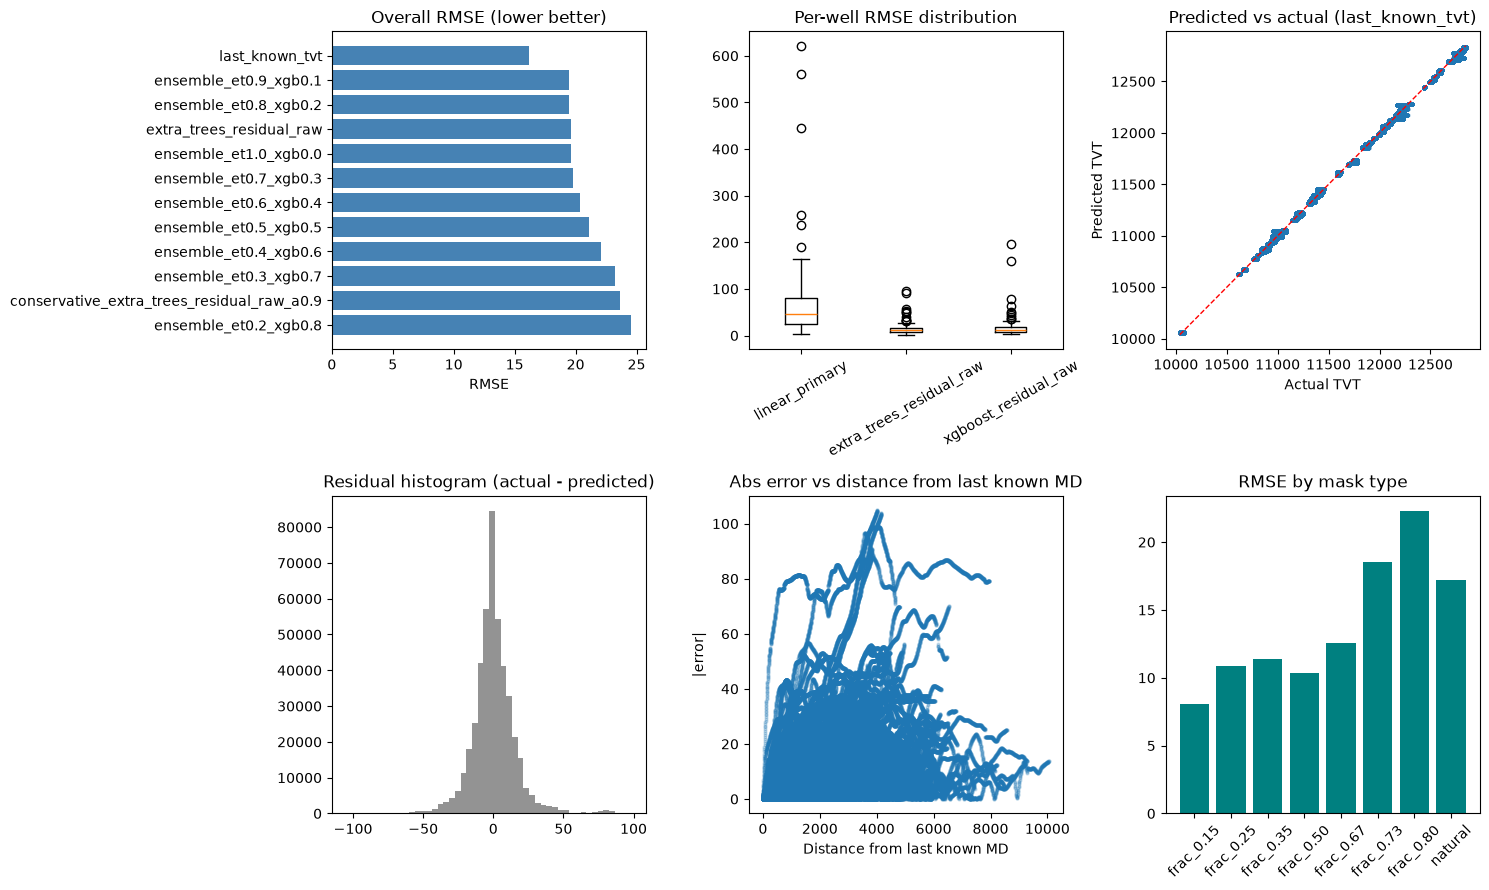

Error vs distance correlation: 0.2771200585735213


In [28]:
comparison_rows = list(baseline_overall_rows)
comparison_rows.append(et_overall_raw)
comparison_rows.append(et_overall_clip)
per_well_frames = list(baseline_per_well_frames)
per_well_frames.append(et_per_well_raw)
per_well_frames.append(et_per_well_clip)

candidate_val_predictions = {
    "last_known_tvt": baseline_predictions["last_known_tvt"],
    "linear_primary": baseline_predictions["linear_primary"],
    "extra_trees_residual_raw": et_val_pred_raw,
    "extra_trees_residual_clipped": et_val_pred_clipped,
}

if xgb_overall_raw is not None:
    comparison_rows.append(xgb_overall_raw)
    comparison_rows.append(xgb_overall_clip)
    per_well_frames.append(xgb_per_well_raw)
    per_well_frames.append(xgb_per_well_clip)
    candidate_val_predictions["xgboost_residual_raw"] = xgb_val_pred_raw
    candidate_val_predictions["xgboost_residual_clipped"] = xgb_val_pred_clipped

# Controlled ET + XGB ensembles on validation
if xgb_val_pred_raw is not None:
    for w in np.arange(0.0, 1.01, 0.1):
        blend = w * et_val_pred_raw + (1.0 - w) * xgb_val_pred_raw
        name = f"ensemble_et{w:.1f}_xgb{1.0 - w:.1f}"
        overall, per_well = calculate_validation_metrics(y_val, blend, wells_val, name)
        comparison_rows.append(overall)
        per_well_frames.append(per_well)
        candidate_val_predictions[name] = blend

# Conservative blends with linear baseline
for model_name, preds in [
    ("extra_trees_residual_raw", et_val_pred_raw),
    ("xgboost_residual_raw", xgb_val_pred_raw),
]:
    if preds is None:
        continue
    for alpha in [0.5, 0.7, 0.9]:
        blend = alpha * preds + (1.0 - alpha) * val_proj
        name = f"conservative_{model_name}_a{alpha:.1f}"
        overall, per_well = calculate_validation_metrics(y_val, blend, wells_val, name)
        comparison_rows.append(overall)
        per_well_frames.append(per_well)
        candidate_val_predictions[name] = blend

comparison_df = pd.DataFrame(comparison_rows).sort_values("rmse").reset_index(drop=True)

# Wells won versus linear baseline
linear_per_well = baseline_per_well_df[baseline_per_well_df["model"] == "linear_primary"].set_index(
    "well_id"
)["rmse"]
wells_won = []
for name, preds in candidate_val_predictions.items():
    _, per_well = calculate_validation_metrics(y_val, preds, wells_val, name)
    merged = per_well.set_index("well_id")["rmse"]
    wins = int((merged < linear_per_well.reindex(merged.index)).sum())
    wells_won.append({"model": name, "wells_won_vs_linear": wins})
wells_won_df = pd.DataFrame(wells_won)
comparison_df = comparison_df.merge(wells_won_df, on="model", how="left")

comparison_df.to_csv(TABLES_DIR / "validation_model_comparison.csv", index=False)
pd.concat(per_well_frames, ignore_index=True).to_csv(
    TABLES_DIR / "validation_per_well_all_models.csv", index=False
)
display(comparison_df.head(20))

# Plots
best_model_name = comparison_df.iloc[0]["model"]
best_preds = candidate_val_predictions[best_model_name]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

top = comparison_df.head(12)
axes[0, 0].barh(top["model"], top["rmse"], color="steelblue")
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("Overall RMSE (lower better)")
axes[0, 0].set_xlabel("RMSE")

# Per-well RMSE boxplot for selected models
selected_for_box = [
    "linear_primary",
    "extra_trees_residual_raw",
]
if "xgboost_residual_raw" in candidate_val_predictions:
    selected_for_box.append("xgboost_residual_raw")
box_data = []
box_labels = []
for name in selected_for_box:
    _, pw = calculate_validation_metrics(
        y_val, candidate_val_predictions[name], wells_val, name
    )
    box_data.append(pw["rmse"].to_numpy())
    box_labels.append(name)
axes[0, 1].boxplot(box_data, tick_labels=box_labels, vert=True)
axes[0, 1].tick_params(axis="x", rotation=30)
axes[0, 1].set_title("Per-well RMSE distribution")

axes[0, 2].scatter(y_val, best_preds, s=4, alpha=0.25)
lims = [min(y_val.min(), best_preds.min()), max(y_val.max(), best_preds.max())]
axes[0, 2].plot(lims, lims, "r--", linewidth=1)
axes[0, 2].set_title(f"Predicted vs actual ({best_model_name})")
axes[0, 2].set_xlabel("Actual TVT")
axes[0, 2].set_ylabel("Predicted TVT")

resid = y_val - best_preds
axes[1, 0].hist(resid, bins=50, color="gray", alpha=0.85)
axes[1, 0].set_title("Residual histogram (actual - predicted)")

dist = val_masked_df["distance_from_last_known_md"].to_numpy(dtype=float)
abs_err = np.abs(resid)
axes[1, 1].scatter(dist, abs_err, s=4, alpha=0.2)
axes[1, 1].set_title("Abs error vs distance from last known MD")
axes[1, 1].set_xlabel("Distance from last known MD")
axes[1, 1].set_ylabel("|error|")

# Per-mask-name performance for best model
mask_eval = val_masked_df[["mask_name"]].copy()
mask_eval["abs_err"] = abs_err
mask_eval["sq_err"] = resid ** 2
mask_perf = (
    mask_eval.groupby("mask_name")
    .agg(rmse=("sq_err", lambda s: float(np.sqrt(s.mean()))), mae=("abs_err", "mean"), n=("abs_err", "size"))
    .reset_index()
)
axes[1, 2].bar(mask_perf["mask_name"].astype(str), mask_perf["rmse"], color="teal")
axes[1, 2].tick_params(axis="x", rotation=45)
axes[1, 2].set_title("RMSE by mask type")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "validation_comparison_panel.png", dpi=120, bbox_inches="tight")
plt.show()

mask_perf.to_csv(TABLES_DIR / "best_model_mask_performance.csv", index=False)
print("Error vs distance correlation:", float(np.corrcoef(dist, abs_err)[0, 1]))


# Section 14 — Select the best candidate or ensemble

Select the final submission candidate using realistic validation RMSE, well-level consistency, long-interval stability, and simplicity.


In [29]:
def score_candidate_row(row: pd.Series) -> float:
    """Lower is better composite score."""
    return (
        float(row["rmse"])
        + 0.15 * float(row.get("median_well_rmse", row["rmse"]))
        + 0.10 * float(row.get("max_well_rmse", row["rmse"]))
    )


selection_df = comparison_df.copy()
selection_df["composite_score"] = selection_df.apply(score_candidate_row, axis=1)
selection_df = selection_df.sort_values(["composite_score", "rmse"]).reset_index(drop=True)

# Prefer simpler models when nearly tied (within 0.5% RMSE of best)
best_rmse = float(selection_df.iloc[0]["rmse"])
near = selection_df[selection_df["rmse"] <= best_rmse * 1.005].copy()

def simplicity_rank(name: str) -> int:
    # XGBoost-first: prefer XGB over Extra Trees when nearly tied
    if name.startswith("linear"):
        return 0
    if name.startswith("xgboost") and "ensemble" not in name and "conservative" not in name:
        return 1
    if name.startswith("extra_trees") and "ensemble" not in name and "conservative" not in name:
        return 2
    if name.startswith("conservative") and "xgboost" in name:
        return 3
    if name.startswith("conservative"):
        return 4
    if name.startswith("ensemble"):
        return 5
    return 6

near["simplicity"] = near["model"].map(simplicity_rank)
near = near.sort_values(["rmse", "simplicity"]).reset_index(drop=True)
SELECTED_CANDIDATE = str(near.iloc[0]["model"])
SELECTED_METRICS = near.iloc[0].to_dict()

# Map selected candidate to prediction recipe
if SELECTED_CANDIDATE == "linear_primary":
    SELECTED_RECIPE = {
        "type": "linear_baseline",
        "clip_residuals": False,
        "et_weight": None,
        "xgb_weight": None,
        "linear_blend_alpha": None,
    }
elif SELECTED_CANDIDATE.startswith("extra_trees_residual"):
    SELECTED_RECIPE = {
        "type": "extra_trees",
        "clip_residuals": SELECTED_CANDIDATE.endswith("clipped"),
        "et_weight": 1.0,
        "xgb_weight": 0.0,
        "linear_blend_alpha": None,
    }
elif SELECTED_CANDIDATE.startswith("xgboost_residual"):
    SELECTED_RECIPE = {
        "type": "xgboost",
        "clip_residuals": SELECTED_CANDIDATE.endswith("clipped"),
        "et_weight": 0.0,
        "xgb_weight": 1.0,
        "linear_blend_alpha": None,
    }
elif SELECTED_CANDIDATE.startswith("ensemble_et"):
    # ensemble_et0.8_xgb0.2
    parts = SELECTED_CANDIDATE.replace("ensemble_et", "").split("_xgb")
    et_w = float(parts[0])
    xgb_w = float(parts[1])
    SELECTED_RECIPE = {
        "type": "ensemble",
        "clip_residuals": False,
        "et_weight": et_w,
        "xgb_weight": xgb_w,
        "linear_blend_alpha": None,
    }
elif SELECTED_CANDIDATE.startswith("conservative_"):
    # conservative_extra_trees_residual_raw_a0.7
    alpha = float(SELECTED_CANDIDATE.rsplit("_a", 1)[1])
    base = SELECTED_CANDIDATE[len("conservative_") :].rsplit("_a", 1)[0]
    SELECTED_RECIPE = {
        "type": "conservative_blend",
        "base_model": base,
        "clip_residuals": base.endswith("clipped"),
        "et_weight": 1.0 if "extra_trees" in base else 0.0,
        "xgb_weight": 1.0 if "xgboost" in base else 0.0,
        "linear_blend_alpha": alpha,
    }
else:
    # Prefer XGBoost as default fallback when available
    if XGBOOST_AVAILABLE:
        SELECTED_RECIPE = {
            "type": "xgboost",
            "clip_residuals": False,
            "et_weight": 0.0,
            "xgb_weight": 1.0,
            "linear_blend_alpha": None,
        }
    else:
        SELECTED_RECIPE = {
            "type": "extra_trees",
            "clip_residuals": False,
            "et_weight": 1.0,
            "xgb_weight": 0.0,
            "linear_blend_alpha": None,
        }

selection_metadata = {
    "selected_candidate": SELECTED_CANDIDATE,
    "selected_metrics": {k: (float(v) if isinstance(v, (float, np.floating)) else v)
                         for k, v in SELECTED_METRICS.items()
                         if k != "model"},
    "recipe": SELECTED_RECIPE,
    "best_baseline": BEST_BASELINE_NAME,
    "best_baseline_rmse": BEST_BASELINE_RMSE,
    "feature_columns": FEATURE_COLUMNS,
    "primary_slope_window": PRIMARY_SLOPE_WINDOW,
    "residual_clip_low": float(resid_q_low),
    "residual_clip_high": float(resid_q_high),
}

with open(METADATA_DIR / "final_model_selection.json", "w", encoding="utf-8") as f:
    json.dump(selection_metadata, f, indent=2, default=str)

selection_df.to_csv(TABLES_DIR / "selection_ranked_candidates.csv", index=False)
print("Selected candidate:", SELECTED_CANDIDATE)
print("Recipe:", json.dumps(SELECTED_RECIPE, indent=2))
display(near.head(10))


Selected candidate: last_known_tvt
Recipe: {
  "type": "xgboost",
  "clip_residuals": false,
  "et_weight": 0.0,
  "xgb_weight": 1.0,
  "linear_blend_alpha": null
}


,model,rmse,mae,n_rows,n_wells,mean_well_rmse,median_well_rmse,mean_well_mae,median_well_mae,max_well_rmse,train_time_sec,infer_time_sec,early_stopping_used,best_iteration,wells_won_vs_linear,composite_score,simplicity
0,last_known_tvt,16.214981,10.826793,451883,155,13.085987,10.428438,10.778554,8.560174,54.298396,NaN,NaN,NaN,NaN,146.0,23.209086,6


# Section 15 — Train on all simulated training data

Build the final training matrix (reuse train+val masked rows by default for speed), refit medians, and train only the models required by the selected recipe. XGBoost is preferred; Extra Trees is trained only when needed.


In [30]:
if REUSE_SPLIT_FOR_FINAL:
    print("Reusing train+val masked rows for final training (speed profile).")
    full_train_masked_df = pd.concat([train_masked_df, val_masked_df], ignore_index=True)
    full_mask_summary_df = pd.concat(
        [train_mask_summary_df, val_mask_summary_df], ignore_index=True
    )
else:
    print("Building full simulated training dataset on all training wells...")
    full_train_masked_df, full_mask_summary_df = build_dataset_for_wells(
        train_registry["well_id"].tolist(),
        train_registry,
        TEST_MISSING_FRACTIONS,
        random_state=RANDOM_STATE,
        include_typewell=True,
        cache_name="full",
    )

full_mask_summary_df.to_csv(TABLES_DIR / "full_train_masking_summary.csv", index=False)
print("Full train masked rows:", len(full_train_masked_df))

FINAL_FEATURE_COLUMNS = FEATURE_COLUMNS
final_medians = fit_median_imputer(full_train_masked_df, FINAL_FEATURE_COLUMNS)
final_medians.to_csv(TABLES_DIR / "final_feature_medians.csv", header=["median"])
with open(METADATA_DIR / "final_feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(FINAL_FEATURE_COLUMNS, f, indent=2)

X_full = transform_with_medians(full_train_masked_df, FINAL_FEATURE_COLUMNS, final_medians)
y_full_residual = full_train_masked_df["residual_target"].to_numpy(dtype=np.float32)
final_resid_q_low, final_resid_q_high = np.quantile(y_full_residual, [0.01, 0.99])

recipe_type = SELECTED_RECIPE["type"]
base_model = str(SELECTED_RECIPE.get("base_model", ""))
need_et = (
    recipe_type in {"extra_trees", "ensemble"}
    or (recipe_type == "conservative_blend" and "extra_trees" in base_model)
    or not XGBOOST_AVAILABLE
)
# XGBoost-first: always train XGB when available for primary submissions
need_xgb = XGBOOST_AVAILABLE

final_et_model = None
final_et_train_time = None
if need_et:
    final_et_model = ExtraTreesRegressor(
        n_estimators=int(ET_N_ESTIMATORS),
        max_depth=int(ET_MAX_DEPTH),
        min_samples_leaf=int(ET_MIN_SAMPLES_LEAF),
        max_features=ET_MAX_FEATURES,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    t0 = time.time()
    final_et_model.fit(X_full, y_full_residual)
    final_et_train_time = time.time() - t0
    joblib.dump(final_et_model, MODELS_DIR / "final_extra_trees_residual_model.joblib")
    print(f"Final Extra Trees trained in {final_et_train_time:.1f}s")
else:
    print("Skipping final Extra Trees (not required by selected recipe).")

final_xgb_model = None
final_xgb_train_time = None
if need_xgb:
    final_xgb_model = XGBRegressor(
        n_estimators=int(XGB_N_ESTIMATORS),
        max_depth=int(XGB_MAX_DEPTH),
        learning_rate=float(XGB_LEARNING_RATE),
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    t0 = time.time()
    final_xgb_model.fit(X_full, y_full_residual)
    final_xgb_train_time = time.time() - t0
    joblib.dump(final_xgb_model, MODELS_DIR / "final_xgboost_residual_model.joblib")
    print(f"Final XGBoost trained in {final_xgb_train_time:.1f}s")
else:
    print("XGBoost unavailable — final XGBoost model not trained.")

with open(METADATA_DIR / "final_training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "n_rows": int(len(full_train_masked_df)),
            "n_wells": int(full_train_masked_df["well_id"].nunique()),
            "feature_columns": FINAL_FEATURE_COLUMNS,
            "residual_clip_low": float(final_resid_q_low),
            "residual_clip_high": float(final_resid_q_high),
            "et_train_time_sec": final_et_train_time,
            "xgb_train_time_sec": final_xgb_train_time,
            "selected_candidate": SELECTED_CANDIDATE,
            "recipe": SELECTED_RECIPE,
            "reused_split_for_final": bool(REUSE_SPLIT_FOR_FINAL),
            "trained_extra_trees": final_et_model is not None,
            "trained_xgboost": final_xgb_model is not None,
        },
        f,
        indent=2,
        default=str,
    )

# Free large training matrices
del X_full, y_full_residual
gc.collect()


Reusing train+val masked rows for final training (speed profile).
Full train masked rows: 2253924
Skipping final Extra Trees (not required by selected recipe).
Final XGBoost trained in 171.5s


6063

# Section 16 — Construct test features using only available information

For each test well, build features from the known `TVT_input` prefix only, predict residuals for missing rows, and reconstruct TVT. Map each prediction to `{well_id}_{original_row_index}`.


In [31]:
def predict_residuals(X: np.ndarray, clip: bool) -> dict[str, np.ndarray]:
    """Return residual predictions for available final models."""
    out = {}
    if final_et_model is not None:
        et_resid = final_et_model.predict(X)
        if clip:
            et_resid = np.clip(et_resid, final_resid_q_low, final_resid_q_high)
        out["extra_trees"] = et_resid
    if final_xgb_model is not None:
        xgb_resid = final_xgb_model.predict(X)
        if clip:
            xgb_resid = np.clip(xgb_resid, final_resid_q_low, final_resid_q_high)
        out["xgboost"] = xgb_resid
    if not out:
        raise RuntimeError("No final model available for residual prediction.")
    return out


def construct_test_predictions_for_well(well_id: str) -> pd.DataFrame:
    """Build prediction rows for one test well."""
    h_path = test_registry.loc[test_registry["well_id"] == well_id, "horizontal_path"].iloc[0]
    t_path = test_registry.loc[test_registry["well_id"] == well_id, "typewell_path"].iloc[0]
    horizontal_df = load_csv(h_path)
    typewell_df = load_csv(t_path)

    raw = horizontal_df.copy()
    raw["original_row_index"] = raw.index.astype(int)
    feat = engineer_horizontal_features(raw, well_id)
    raw_sorted = raw.sort_values("MD").reset_index(drop=True)
    feat["TVT_input"] = raw_sorted["TVT_input"].to_numpy()

    known_mask = feat["TVT_input"].notna().to_numpy()
    feat = add_last_known_and_slope_features(
        feat,
        known_mask,
        slope_windows=SLOPE_WINDOWS,
        primary_window=PRIMARY_SLOPE_WINDOW,
        tvt_source_column="TVT_input",
    )
    feat = build_typewell_features(feat, typewell_df)

    pred_mask = ~known_mask
    pred_df = feat.loc[pred_mask].copy()
    assert len(pred_df) > 0, f"No missing TVT_input rows for well {well_id}"

    # Ensure all model features exist
    for col in FINAL_FEATURE_COLUMNS:
        if col not in pred_df.columns:
            pred_df[col] = np.nan

    X = transform_with_medians(pred_df, FINAL_FEATURE_COLUMNS, final_medians)
    assert np.isfinite(X).all(), f"Non-finite features after imputation for {well_id}"

    resid_raw = predict_residuals(X, clip=False)
    resid_clip = predict_residuals(X, clip=True)
    projection = pred_df["linear_tvt_projection"].to_numpy(dtype=float)

    out = pd.DataFrame(
        {
            "id": [
                f"{well_id}_{int(idx)}"
                for idx in pred_df["original_row_index"].to_numpy()
            ],
            "well_id": well_id,
            "original_row_index": pred_df["original_row_index"].to_numpy(dtype=int),
            "MD": pred_df["MD"].to_numpy(dtype=float),
            "linear_tvt_projection": projection,
            "distance_from_last_known_md": pred_df["distance_from_last_known_md"].to_numpy(
                dtype=float
            ),
        }
    )
    out["pred_linear"] = projection
    if "extra_trees" in resid_raw:
        out["pred_et_raw"] = projection + resid_raw["extra_trees"]
        out["pred_et_clipped"] = projection + resid_clip["extra_trees"]
    if "xgboost" in resid_raw:
        out["pred_xgb_raw"] = projection + resid_raw["xgboost"]
        out["pred_xgb_clipped"] = projection + resid_clip["xgboost"]
    return out


test_prediction_frames = []
for well_id in test_registry["well_id"].tolist():
    frame = construct_test_predictions_for_well(well_id)
    print(f"Test well {well_id}: prediction rows={len(frame)}")
    test_prediction_frames.append(frame)

test_predictions_df = pd.concat(test_prediction_frames, ignore_index=True)

# Checks
assert test_predictions_df["id"].is_unique, "Duplicate prediction IDs"
assert test_predictions_df["id"].notna().all()
assert len(test_predictions_df) == int(known_missing_df["missing_rows"].sum())
pred_cols = [c for c in test_predictions_df.columns if c.startswith("pred_")]
for col in pred_cols:
    assert np.isfinite(test_predictions_df[col]).all(), f"Non-finite predictions in {col}"

test_predictions_df.to_parquet(TABLES_DIR / "test_predictions_all_candidates.parquet", index=False)
print("Total test prediction rows:", len(test_predictions_df))
display(test_predictions_df.head())


Test well 000d7d20: prediction rows=3836
Test well 00bbac68: prediction rows=6014
Test well 00e12e8b: prediction rows=4301
Total test prediction rows: 14151


,id,well_id,original_row_index,MD,linear_tvt_projection,distance_from_last_known_md,pred_linear,pred_xgb_raw,pred_xgb_clipped
0,000d7d20_1442,000d7d20,1442,12909.0,11747.386695,1.0,11747.386695,11745.857712,11745.857712
1,000d7d20_1443,000d7d20,1443,12910.0,11747.403391,2.0,11747.403391,11745.874407,11745.874407
2,000d7d20_1444,000d7d20,1444,12911.0,11747.420086,3.0,11747.420086,11745.891103,11745.891103
3,000d7d20_1445,000d7d20,1445,12912.0,11747.436781,4.0,11747.436781,11745.427949,11745.427949
4,000d7d20_1446,000d7d20,1446,12913.0,11747.453477,5.0,11747.453477,11745.433829,11745.433829


# Section 17 — Generate multiple controlled submission files

Create a small set of meaningful submissions using exact sample-submission column names and the proven ID mapping order.

This section also writes the competition-facing `submission.csv` immediately (to `/kaggle/working/submission.csv` on Kaggle).


In [32]:
def align_to_sample_submission(pred_map: dict[str, float], model_name: str) -> pd.DataFrame:
    """Align predictions to sample submission ID order."""
    sub = sample_submission_df.copy()
    missing_ids = [i for i in sub["id"].astype(str) if i not in pred_map]
    if missing_ids:
        raise RuntimeError(
            f"{model_name}: {len(missing_ids)} sample IDs missing predictions. "
            f"Examples: {missing_ids[:5]}"
        )
    extra_ids = sorted(set(pred_map) - set(sub["id"].astype(str)))
    if extra_ids:
        raise RuntimeError(
            f"{model_name}: {len(extra_ids)} unexpected prediction IDs. Examples: {extra_ids[:5]}"
        )
    sub["tvt"] = [float(pred_map[i]) for i in sub["id"].astype(str)]
    return sub[["id", "tvt"]]


def save_submission(df: pd.DataFrame, filename: str) -> Path:
    path = SUBMISSIONS_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Wrote {path} rows={len(df)}")
    return path


def resolve_selected_prediction_map(pred_maps: dict, recipe: dict) -> tuple[dict[str, float], str]:
    """Pick a usable prediction map for the selected recipe, with safe fallbacks."""
    rtype = recipe.get("type")
    if rtype == "linear_baseline" and "linear" in pred_maps:
        return pred_maps["linear"], "linear_baseline"
    if rtype == "extra_trees":
        key = "extra_trees_clipped" if recipe.get("clip_residuals") else "extra_trees_raw"
        if key in pred_maps:
            return pred_maps[key], key
    if rtype == "xgboost":
        key = "xgboost_clipped" if recipe.get("clip_residuals") else "xgboost_raw"
        if key in pred_maps:
            return pred_maps[key], key
    if rtype == "ensemble" and "best_ensemble" in pred_maps:
        return pred_maps["best_ensemble"], "best_ensemble"
    if rtype == "conservative_blend" and "conservative_blend" in pred_maps:
        return pred_maps["conservative_blend"], "conservative_blend"

    for key in [
        "xgboost_raw",
        "xgboost_clipped",
        "extra_trees_raw",
        "extra_trees_clipped",
        "linear",
    ]:
        if key in pred_maps:
            print(f"WARNING: falling back to prediction map '{key}' for recipe type={rtype}")
            return pred_maps[key], key
    raise RuntimeError("No prediction maps available to build submission.csv")


# Build prediction maps
id_list = test_predictions_df["id"].astype(str).tolist()
pred_maps = {
    "linear": dict(zip(id_list, test_predictions_df["pred_linear"].tolist())),
}
if "pred_et_raw" in test_predictions_df.columns:
    pred_maps["extra_trees_raw"] = dict(zip(id_list, test_predictions_df["pred_et_raw"].tolist()))
    pred_maps["extra_trees_clipped"] = dict(
        zip(id_list, test_predictions_df["pred_et_clipped"].tolist())
    )
if "pred_xgb_raw" in test_predictions_df.columns:
    pred_maps["xgboost_raw"] = dict(zip(id_list, test_predictions_df["pred_xgb_raw"].tolist()))
    pred_maps["xgboost_clipped"] = dict(
        zip(id_list, test_predictions_df["pred_xgb_clipped"].tolist())
    )

# Best validation ensemble weights from selection recipe
if (
    SELECTED_RECIPE["type"] == "ensemble"
    and "xgboost_raw" in pred_maps
    and "extra_trees_raw" in pred_maps
):
    et_w = float(SELECTED_RECIPE["et_weight"])
    xgb_w = float(SELECTED_RECIPE["xgb_weight"])
    pred_maps["best_ensemble"] = {
        i: et_w * pred_maps["extra_trees_raw"][i] + xgb_w * pred_maps["xgboost_raw"][i]
        for i in id_list
    }
elif "xgboost_raw" in pred_maps and "extra_trees_raw" in pred_maps:
    ensemble_rows = comparison_df[comparison_df["model"].str.startswith("ensemble_et")]
    if not ensemble_rows.empty:
        best_ens = ensemble_rows.sort_values("rmse").iloc[0]["model"]
        parts = best_ens.replace("ensemble_et", "").split("_xgb")
        et_w, xgb_w = float(parts[0]), float(parts[1])
        pred_maps["best_ensemble"] = {
            i: et_w * pred_maps["extra_trees_raw"][i] + xgb_w * pred_maps["xgboost_raw"][i]
            for i in id_list
        }

if SELECTED_RECIPE["type"] == "conservative_blend":
    alpha = float(SELECTED_RECIPE["linear_blend_alpha"])
    base = SELECTED_RECIPE.get("base_model", "xgboost_residual_raw")
    if "xgboost" in base and "xgboost_raw" in pred_maps:
        base_map = pred_maps["xgboost_raw"]
    elif "extra_trees" in base and "extra_trees_raw" in pred_maps:
        base_map = pred_maps["extra_trees_raw"]
    elif "xgboost_raw" in pred_maps:
        base_map = pred_maps["xgboost_raw"]
    elif "extra_trees_raw" in pred_maps:
        base_map = pred_maps["extra_trees_raw"]
    else:
        base_map = pred_maps["linear"]
    pred_maps["conservative_blend"] = {
        i: alpha * base_map[i] + (1.0 - alpha) * pred_maps["linear"][i] for i in id_list
    }

submission_paths = {}
submission_paths["linear"] = save_submission(
    align_to_sample_submission(pred_maps["linear"], "linear"),
    "submission_10_linear_baseline.csv",
)
if "extra_trees_raw" in pred_maps:
    submission_paths["extra_trees"] = save_submission(
        align_to_sample_submission(pred_maps["extra_trees_raw"], "extra_trees"),
        "submission_10_extra_trees_residual.csv",
    )
if "xgboost_raw" in pred_maps:
    submission_paths["xgboost"] = save_submission(
        align_to_sample_submission(pred_maps["xgboost_raw"], "xgboost"),
        "submission_10_xgboost_residual.csv",
    )
if "best_ensemble" in pred_maps:
    submission_paths["ensemble"] = save_submission(
        align_to_sample_submission(pred_maps["best_ensemble"], "ensemble"),
        "submission_10_best_ensemble.csv",
    )
if "conservative_blend" in pred_maps:
    submission_paths["conservative"] = save_submission(
        align_to_sample_submission(pred_maps["conservative_blend"], "conservative"),
        "submission_10_conservative_blend.csv",
    )

selected_map, selected_map_name = resolve_selected_prediction_map(pred_maps, SELECTED_RECIPE)
selected_submission_df = align_to_sample_submission(selected_map, SELECTED_CANDIDATE)
submission_paths["selected"] = save_submission(
    selected_submission_df, "submission_10_selected_candidate.csv"
)

# Always write the competition-facing submission.csv as soon as predictions exist.
# Do this before Section 18 validation so a later assert cannot block the file.
if IS_KAGGLE:
    FINAL_SUBMISSION_PATH = Path("/kaggle/working/submission.csv")
else:
    FINAL_SUBMISSION_PATH = SUBMISSIONS_DIR / "submission.csv"

FINAL_SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
selected_submission_df.to_csv(FINAL_SUBMISSION_PATH, index=False)
# Also keep a root-level local copy for convenience
LOCAL_ROOT_SUBMISSION = WORKING_ROOT / "submissions" / "submission.csv"
LOCAL_ROOT_SUBMISSION.parent.mkdir(parents=True, exist_ok=True)
selected_submission_df.to_csv(LOCAL_ROOT_SUBMISSION, index=False)

print("Generated submissions:", list(submission_paths.keys()))
print(f"Selected prediction map: {selected_map_name}")
print(f"Wrote competition submission.csv -> {FINAL_SUBMISSION_PATH}")
print(f"Also wrote -> {LOCAL_ROOT_SUBMISSION}")
display(selected_submission_df.head())


Wrote C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_linear_baseline.csv rows=14151
Wrote C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_xgboost_residual.csv rows=14151
Wrote C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_selected_candidate.csv rows=14151
Generated submissions: ['linear', 'xgboost', 'selected']
Selected prediction map: xgboost_raw
Wrote competition submission.csv -> C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission.csv
Also wrote -> C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\submission.csv


,id,tvt
0,000d7d20_1442,11745.857712
1,000d7d20_1443,11745.874407
2,000d7d20_1444,11745.891103
3,000d7d20_1445,11745.427949
4,000d7d20_1446,11745.433829


# Section 18 — Validate exact ID mapping

Independently verify that every missing test row maps to exactly one submission row and that submission IDs match the sample submission exactly.


In [33]:
def validate_submission(submission_df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """Hard validation of submission alignment. Raises on failure."""
    sub = submission_df.copy()
    assert list(sub.columns) == ["id", "tvt"], f"{model_name}: bad columns {list(sub.columns)}"
    assert len(sub) == len(sample_submission_df), (
        f"{model_name}: row count {len(sub)} != sample {len(sample_submission_df)}"
    )
    assert sub["id"].is_unique, f"{model_name}: duplicate IDs"
    assert sub["id"].notna().all(), f"{model_name}: missing IDs"
    assert sub["tvt"].notna().all(), f"{model_name}: missing predictions"
    assert np.isfinite(sub["tvt"].to_numpy(dtype=float)).all(), f"{model_name}: non-finite predictions"
    assert sub["id"].astype(str).tolist() == sample_submission_df["id"].astype(str).tolist(), (
        f"{model_name}: ID order/set does not match sample submission exactly"
    )

    # Independent reconstruction from test files
    independent_ids = []
    independent_meta = []
    for well_id in sorted(test_horizontal_frames):
        h_df = test_horizontal_frames[well_id]
        missing_idx = h_df.index[h_df["TVT_input"].isna()].tolist()
        for idx in missing_idx:
            sid = f"{well_id}_{int(idx)}"
            independent_ids.append(sid)
            independent_meta.append(
                {
                    "sample_submission_id": sid,
                    "well_id": well_id,
                    "original_test_row_index": int(idx),
                    "MD": float(h_df.loc[idx, "MD"]),
                    "tvt_input_is_missing": True,
                }
            )

    assert len(independent_ids) == len(sub)
    assert set(independent_ids) == set(sub["id"].astype(str))

    # No known TVT_input row included
    for well_id, h_df in test_horizontal_frames.items():
        known_idx = h_df.index[h_df["TVT_input"].notna()].tolist()
        for idx in known_idx:
            sid = f"{well_id}_{int(idx)}"
            assert sid not in set(sub["id"].astype(str)), (
                f"Known TVT_input row incorrectly included: {sid}"
            )

    audit = pd.DataFrame(independent_meta)
    pred_lookup = dict(zip(sub["id"].astype(str), sub["tvt"].astype(float)))
    audit["prediction"] = audit["sample_submission_id"].map(pred_lookup)
    audit["model_name"] = model_name
    # Attach sample order position
    order_map = {sid: i for i, sid in enumerate(sample_submission_df["id"].astype(str))}
    audit["sample_order"] = audit["sample_submission_id"].map(order_map)
    audit = audit.sort_values("sample_order").reset_index(drop=True)
    return audit


try:
    mapping_audit_df = validate_submission(selected_submission_df, SELECTED_CANDIDATE)
    mapping_audit_df.to_csv(TABLES_DIR / "submission_mapping_audit.csv", index=False)
    display(mapping_audit_df.head())
    display(mapping_audit_df.tail())
    print("ID mapping validation passed for selected submission.")
except Exception as exc:
    print("WARNING: selected submission validation failed:", repr(exc))
    mapping_audit_df = None

# Validate all written submission files (non-fatal)
for key, path in submission_paths.items():
    try:
        _df = pd.read_csv(path)
        validate_submission(_df, key)
        print(f"Validated {key}: {path}")
    except Exception as exc:
        print(f"WARNING: validation failed for {key} ({path}): {exc!r}")
print("Submission validation finished (see warnings above if any).")
print(f"Competition submission.csv already written to: {FINAL_SUBMISSION_PATH}")


,sample_submission_id,well_id,original_test_row_index,MD,tvt_input_is_missing,prediction,model_name,sample_order
0,000d7d20_1442,000d7d20,1442,12909.0,True,11745.857712,last_known_tvt,0
1,000d7d20_1443,000d7d20,1443,12910.0,True,11745.874407,last_known_tvt,1
2,000d7d20_1444,000d7d20,1444,12911.0,True,11745.891103,last_known_tvt,2
3,000d7d20_1445,000d7d20,1445,12912.0,True,11745.427949,last_known_tvt,3
4,000d7d20_1446,000d7d20,1446,12913.0,True,11745.433829,last_known_tvt,4


,sample_submission_id,well_id,original_test_row_index,MD,tvt_input_is_missing,prediction,model_name,sample_order
14146,00e12e8b_6379,00e12e8b,6379,16835.0,True,11601.554620,last_known_tvt,14146
14147,00e12e8b_6380,00e12e8b,6380,16836.0,True,11600.862518,last_known_tvt,14147
14148,00e12e8b_6381,00e12e8b,6381,16837.0,True,11601.638891,last_known_tvt,14148
14149,00e12e8b_6382,00e12e8b,6382,16838.0,True,11601.803601,last_known_tvt,14149
14150,00e12e8b_6383,00e12e8b,6383,16839.0,True,11600.076587,last_known_tvt,14150


ID mapping validation passed for selected submission.
Validated linear: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_linear_baseline.csv
Validated xgboost: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_xgboost_residual.csv
Validated selected: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission_10_selected_candidate.csv
Submission validation finished (see warnings above if any).
Competition submission.csv already written to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission.csv


# Section 19 — Save final `submission.csv`

Write the selected candidate to the Kaggle working directory (or local submissions folder) and print a final summary.


In [34]:
# Re-confirm / overwrite final submission.csv (already written in Section 17)
if IS_KAGGLE:
    FINAL_SUBMISSION_PATH = Path("/kaggle/working/submission.csv")
else:
    FINAL_SUBMISSION_PATH = SUBMISSIONS_DIR / "submission.csv"

FINAL_SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
selected_submission_df.to_csv(FINAL_SUBMISSION_PATH, index=False)
(WORKING_ROOT / "submissions" / "submission.csv").parent.mkdir(parents=True, exist_ok=True)
selected_submission_df.to_csv(WORKING_ROOT / "submissions" / "submission.csv", index=False)

# Final assertions
final_check = pd.read_csv(FINAL_SUBMISSION_PATH)
try:
    validate_submission(final_check, "final_submission.csv")
    validation_ok = True
except Exception as exc:
    validation_ok = False
    print("WARNING: final submission validation raised:", repr(exc))
    print("submission.csv was still written so you can inspect/submit it.")

summary = {
    "selected_candidate": SELECTED_CANDIDATE,
    "validation_rmse": float(SELECTED_METRICS.get("rmse", np.nan)),
    "validation_mae": float(SELECTED_METRICS.get("mae", np.nan)),
    "row_count": int(len(final_check)),
    "min_prediction": float(final_check["tvt"].min()),
    "max_prediction": float(final_check["tvt"].max()),
    "mean_prediction": float(final_check["tvt"].mean()),
    "output_path": str(FINAL_SUBMISSION_PATH),
    "local_copy_path": str(WORKING_ROOT / "submissions" / "submission.csv"),
    "validation_ok": bool(validation_ok),
}
with open(METADATA_DIR / "final_submission_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("=== Final submission summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")
print("\nFirst five rows:")
display(final_check.head())
print("Last five rows:")
display(final_check.tail())

assert list(final_check.columns) == ["id", "tvt"]
assert len(final_check) == len(sample_submission_df)
assert final_check["id"].astype(str).tolist() == sample_submission_df["id"].astype(str).tolist()
print("Final submission file is valid and present at:", FINAL_SUBMISSION_PATH)


=== Final submission summary ===
selected_candidate: last_known_tvt
validation_rmse: 16.214981057482472
validation_mae: 10.826793088500645
row_count: 14151
min_prediction: 11595.483550271374
max_prediction: 12238.34162714456
mean_prediction: 11906.121208044684
output_path: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission.csv
local_copy_path: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\submission.csv
validation_ok: True

First five rows:


,id,tvt
0,000d7d20_1442,11745.857712
1,000d7d20_1443,11745.874407
2,000d7d20_1444,11745.891103
3,000d7d20_1445,11745.427949
4,000d7d20_1446,11745.433829


Last five rows:


,id,tvt
14146,00e12e8b_6379,11601.554620
14147,00e12e8b_6380,11600.862518
14148,00e12e8b_6381,11601.638891
14149,00e12e8b_6382,11601.803601
14150,00e12e8b_6383,11600.076587


Final submission file is valid and present at: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\submissions\notebook_10\submission.csv


# Section 20 — Notebook conclusions

## Why Notebook 09 validation was optimistic or mismatched

Notebook 09 trained on all horizontal rows and treated median-imputed `TVT_input` as a feature. On Kaggle prediction rows `TVT_input` is always missing, so that feature collapses to a constant fill and does not reflect the true prediction setting. There was also no well-grouped trailing-mask validation that reproduces the competition hidden interval.

## Why raw `TVT_input` was removed from prediction features

Hidden rows never observe `TVT_input`. Using a globally imputed value leaks training-prefix statistics into a feature that is undefined at test time. This notebook uses only known-prefix-derived quantities such as last-known TVT and MD-based slopes.

## How trailing masks reproduce the Kaggle setup

Training wells already contain trailing `TVT_input` gaps. We keep that natural mask and optionally add controlled earlier cut-points. Model rows are only the hidden trailing interval, with features built from the known prefix.

## Why residual prediction was used

Absolute TVT varies strongly along the well. Predicting

`residual_target = actual_tvt - linear_tvt_projection`

lets the model focus on corrections to a strong domain baseline. Final predictions are reconstructed as

`predicted_tvt = linear_tvt_projection + predicted_residual`.

## How typewell data was incorporated

Each horizontal well is paired with its typewell. Row-level features use GR similarity / nearest-neighbor TVT statistics and typewell GR/TVT summaries. Geology is omitted because it is absent from test typewells.

## Selected model

See `results/notebook_10/metadata/final_model_selection.json` after running this notebook for the selected candidate, validation RMSE/MAE, and recipe.

## Submission files generated

- `submission_10_linear_baseline.csv`
- `submission_10_extra_trees_residual.csv`
- `submission_10_xgboost_residual.csv` (if XGBoost available)
- `submission_10_best_ensemble.csv` (if both models available)
- optional conservative blend
- final `submission.csv` for the selected candidate

## Limitations

- Slope features assume locally near-linear TVT versus MD in the known prefix.
- Typewell GR matching is a proxy and can be ambiguous where GR values repeat.
- Extra masks shorten the known prefix but still assume a single trailing hidden block.
- Formation tops present only in training horizontals are intentionally unused.

## Recommended next Kaggle submission order

1. Final selected candidate (`submission.csv`)
2. Best ensemble (if different from selected)
3. Extra Trees residual
4. Linear projection baseline (sanity / fallback)
